# Notable Individuals Across World Regions & Dynasties

Evolution of the number of notable individuals matched to major polities across **14 world regions**,
using the `individuals_cliopatria` table (Cliopatria polity matching against Wikidata individuals).

**Regions covered:**
1. Western Europe
2. Eastern Europe
3. Arab & Islamic World
4. Mesopotamia & Ancient Persia
5. Indian World
6. East Asia (Japan & Korea)
7. Southeast Asia
8. Africa
9. North America
10. South America
11. Oceania
12. Greek World
13. Roman / Latin World
14. Chinese World

Each region shows a **polity timeline** with a **log-scale line chart** of individuals per 50-year period

In [1]:
import sqlite3
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import numpy as np

matplotlib.rcParams['figure.figsize'] = (18, 10)
matplotlib.rcParams['figure.dpi'] = 120

DB_PATH = '../data/humans_clean.sqlite3'
conn = sqlite3.connect(DB_PATH)

## Helper Functions

In [2]:
import os

PLOT_DIR = 'dynasty_plots'
os.makedirs(PLOT_DIR, exist_ok=True)


def half_century_of(year):
    """Round a year to the nearest 50, truncating toward zero.
    e.g. 1687 -> 1650, 1702 -> 1700, 2 -> 0, -3 -> 0, -53 -> -50."""
    if year == 0:
        return 0
    return int(math.copysign(1, year)) * (abs(year) // 50) * 50


def get_period_distribution(conn, polity_id):
    """Get count of individuals per 50-year period for a polity."""
    cur = conn.execute('''
        SELECT ic.floruit_period_start as year, COUNT(*) as cnt
        FROM individuals_cliopatria ic
        WHERE ic.polity_id = ?
          AND ic.floruit_period_start IS NOT NULL
        GROUP BY ic.floruit_period_start
        ORDER BY ic.floruit_period_start
    ''', (polity_id,))
    periods = {}
    for year, cnt in cur:
        if year is None:
            continue
        period = half_century_of(year)
        periods[period] = periods.get(period, 0) + cnt
    return periods


def get_time_range(conn, polity_id):
    """Get the min/max year range from polity periods."""
    cur = conn.execute(
        'SELECT MIN(from_year), MAX(to_year) FROM polities_periods_cliopatria WHERE polity_id = ?',
        (polity_id,)
    )
    return cur.fetchone()


def load_region_data(conn, polities):
    """Load data for a list of polities. Returns list of dicts."""
    data = []
    print(f"{'Polity':<30s}  {'Period':>16s}  {'Individuals':>12s}  {'Bins':>6s}")
    print('-' * 70)
    for pid, name, color, is_major in polities:
        fr, to = get_time_range(conn, pid)
        periods = get_period_distribution(conn, pid)
        total = sum(periods.values())
        data.append({
            'id': pid, 'name': name, 'color': color, 'is_major': is_major,
            'from': fr, 'to': to, 'periods': periods, 'total': total,
        })
        fr_s = f"{abs(fr)} BCE" if fr < 0 else f"{fr} CE"
        to_s = f"{abs(to)} BCE" if to < 0 else f"{to} CE"
        marker = '*' if is_major else ' '
        print(f"{marker} {name:<28s}  {fr_s:>7s} - {to_s:<6s}  {total:>12,d}  {len(periods):>6d}")
    return data


def plot_timeline_and_lines(data, region_name, xlim, save_name=None):
    """Plot polity timeline (top) + log-scale line chart (bottom), binned per 50 years."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 11),
                                    gridspec_kw={'height_ratios': [1, 1.8]})

    # --- Top panel: timeline bars ---
    y_pos = 0
    for d in data:
        width = d['to'] - d['from']
        alpha = 0.9 if d['is_major'] else 0.5
        lw = 2 if d['is_major'] else 1
        ax1.barh(y_pos, width, left=d['from'], height=0.7,
                 color=d['color'], alpha=alpha, edgecolor='black', linewidth=lw)
        mid = d['from'] + width / 2
        fs = 8 if d['is_major'] else 6
        fw = 'bold' if d['is_major'] else 'normal'
        ax1.text(mid, y_pos, d['name'], ha='center', va='center',
                 fontsize=fs, fontweight=fw, color='white',
                 path_effects=[pe.withStroke(linewidth=2, foreground='black')])
        y_pos += 1

    ax1.set_yticks([])
    ax1.set_title(region_name, fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlim(*xlim)
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax1.grid(axis='x', alpha=0.3)
    ax1.set_facecolor('#f8f8f8')
    ax1.invert_yaxis()

    # --- Bottom panel: individuals per 50-year period (log scale) ---
    for d in data:
        if d['total'] < 5:
            continue
        pds = sorted([p for p in d['periods'].keys() if xlim[0] <= p <= xlim[1]])
        if not pds:
            continue
        counts = [d['periods'].get(p, 0) for p in pds]
        lw = 2.5 if d['is_major'] else 1.2
        alpha = 0.9 if d['is_major'] else 0.6
        ls = '-' if d['is_major'] else '--'
        ms = 4 if d['is_major'] else 2
        ax2.plot(pds, counts, color=d['color'], linewidth=lw, alpha=alpha,
                 linestyle=ls, marker='o', markersize=ms,
                 label=f"{d['name']} ({d['total']:,})")

    ax2.set_yscale('log')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax2.set_xlabel('Half-Century', fontsize=12)
    ax2.set_ylabel('Number of Individuals (log scale)', fontsize=12)
    ax2.set_xlim(*xlim)
    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    ax2.grid(True, alpha=0.3, which='both')
    ax2.set_facecolor('#f8f8f8')

    for d in data:
        if d['is_major']:
            ax2.axvspan(d['from'], d['to'], alpha=0.08, color=d['color'])

    ax2.legend(fontsize=7, loc='upper left', ncol=2, framealpha=0.9)
    plt.tight_layout()

    if save_name:
        fig.savefig(os.path.join(PLOT_DIR, save_name), dpi=150, bbox_inches='tight')
        print(f"  Saved: {os.path.join(PLOT_DIR, save_name)}")

    plt.show()

---
## 1. Western Europe

In [3]:
western_europe = [
    (91,   'Roman Republic',     '#8B0000', True),
    (208,  'Roman Empire',       '#DC143C', True),
    (275,  'Western Roman',      '#CD5C5C', False),
    (274,  'Eastern Roman',      '#B22222', False),
    (407,  'Carolingian Empire', '#FF8C00', True),
    (537,  'Kingdom of England', '#2E8B57', True),
    (583,  'Kingdom of France',  '#4169E1', True),
    (527,  'Holy Roman Empire',  '#DAA520', True),
    (351,  'Kingdom of Italy',   '#FF4500', True),
    (425,  'Papal States',       '#9370DB', False),
    (403,  'Republic of Venice', '#20B2AA', False),
    (539,  'Kingdom of Denmark', '#6495ED', False),
    (1003, 'Kingdom of Spain',   '#FF6347', True),
    (695,  'Kingdom of Portugal','#228B22', False),
    (954,  'Habsburg Monarchy',  '#8B4513', True),
    (1048, 'Dutch Republic',     '#FF7F50', False),
    (1102, 'Kingdom of Prussia', '#4682B4', False),
    (772,  'Republic of Florence','#D2691E', False),
]
we_data = load_region_data(conn, western_europe)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Roman Republic                550 BCE - 327 BCE           120       6
* Roman Empire                    43 CE - 237 CE             5       3
  Western Roman                  402 CE - 554 CE             0       0
  Eastern Roman                  402 CE - 409 CE             2       1
* Carolingian Empire             741 CE - 1009 CE             0       0
* Kingdom of England             936 CE - 969 CE             0       0
* Kingdom of France             1010 CE - 1093 CE             0       0
* Holy Roman Empire              926 CE - 1098 CE             6       3
* Kingdom of Italy               587 CE - 632 CE             0       0
  Papal States                   778 CE - 910 CE             6       3
  Republic of Venice             724 CE - 925 CE            38       4
  Kingdom of Denmark             947 CE - 1406 CE           107       9
*

  Saved: dynasty_plots/01_western_europe.png


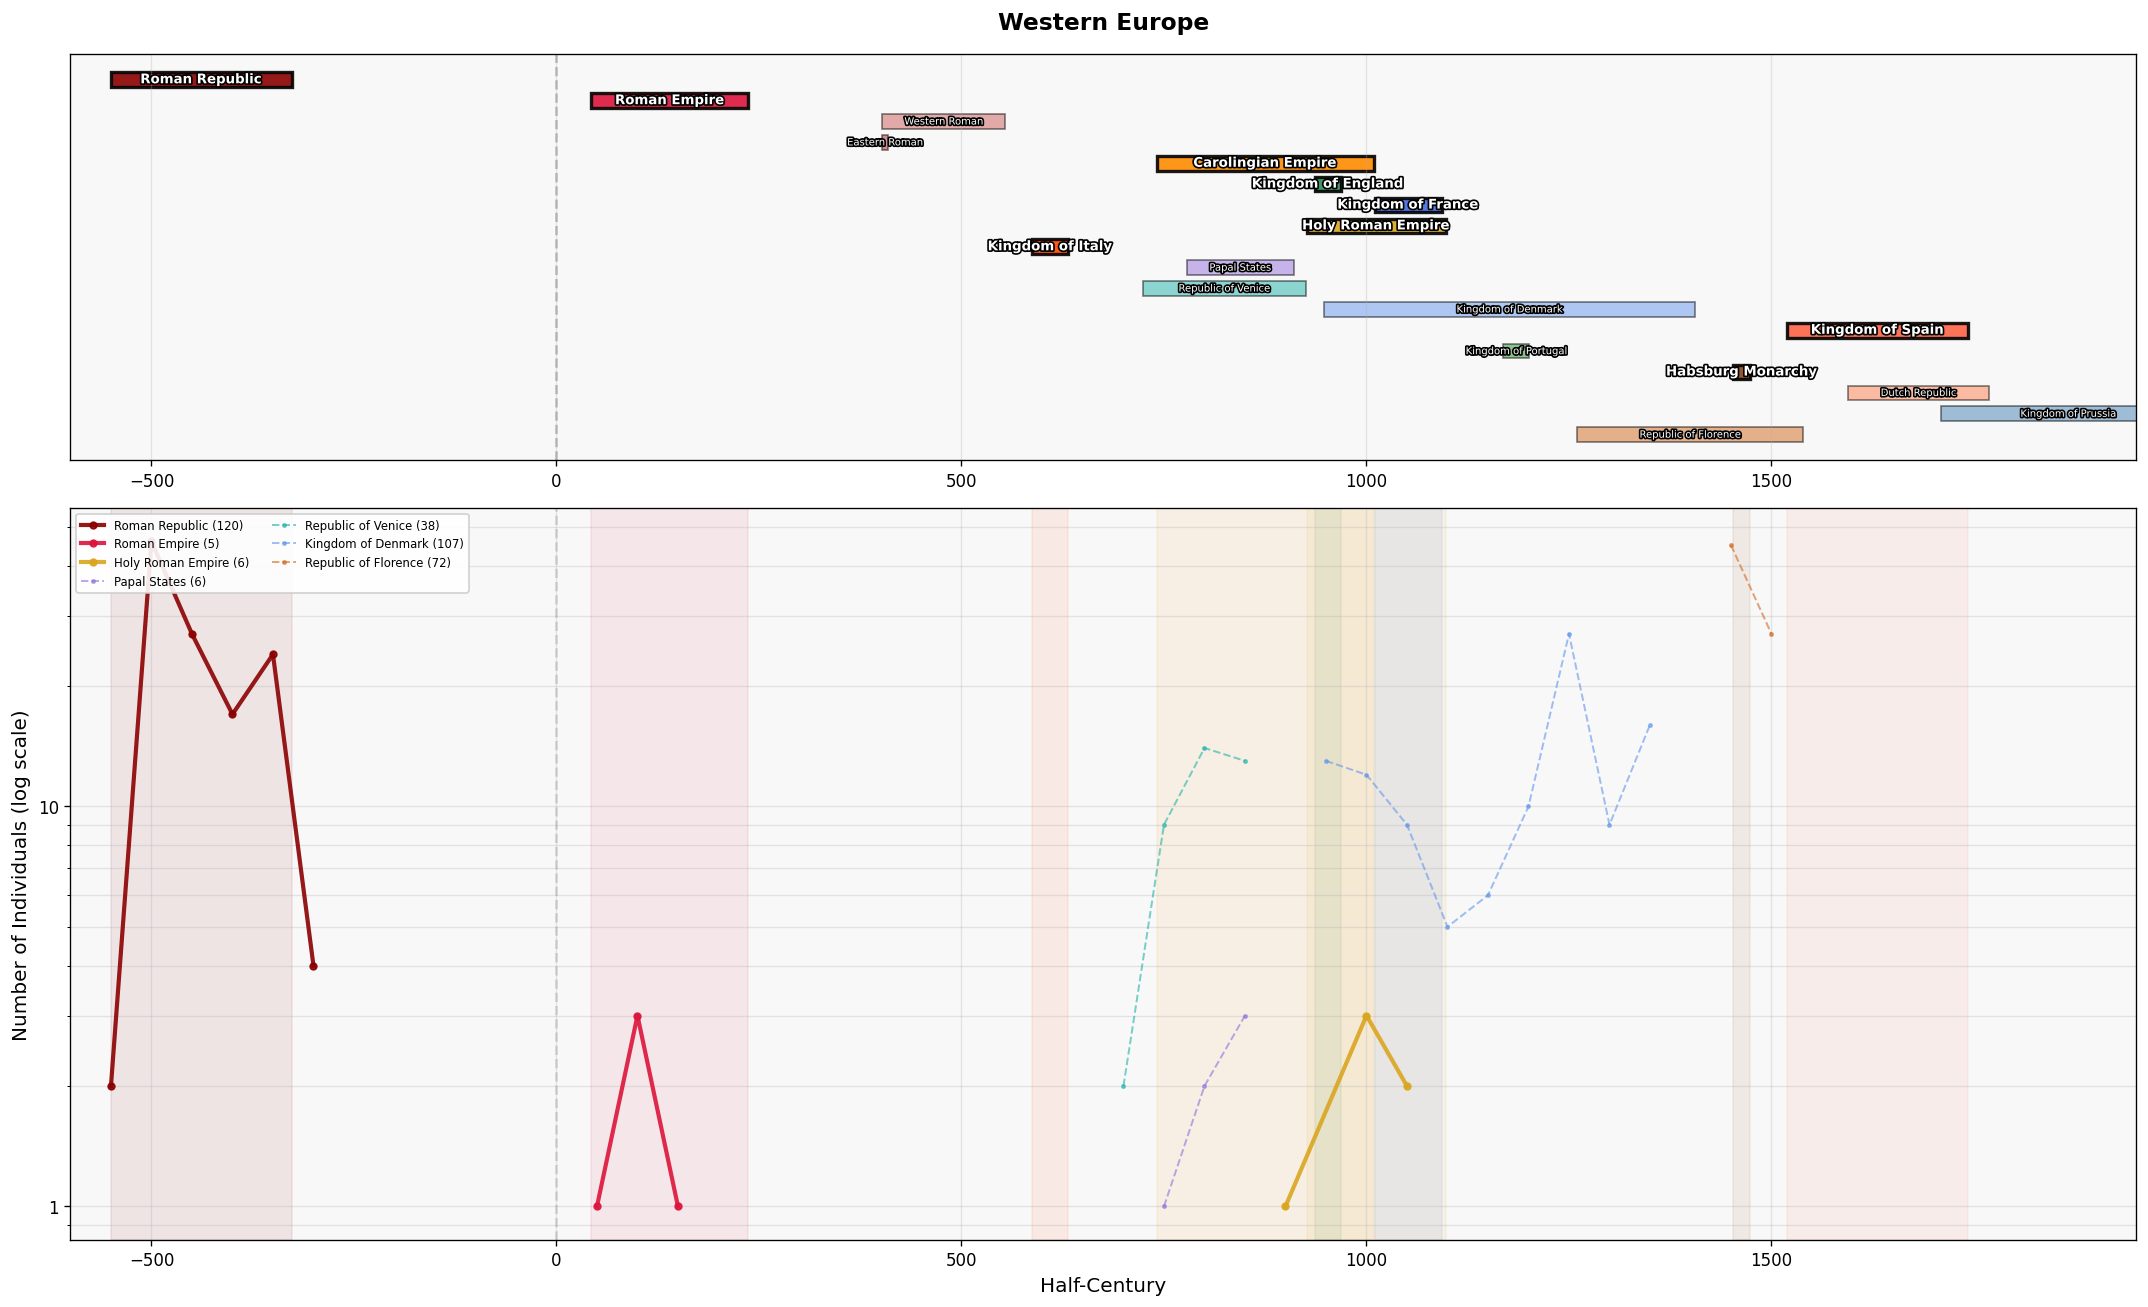

In [4]:
plot_timeline_and_lines(we_data, 'Western Europe', (-600, 1950), save_name='01_western_europe.png')

---
## 2. Eastern Europe

In [5]:
eastern_europe = [
    (380,  'Byzantine Empire',      '#9370DB', True),
    (399,  'First Bulgarian Empire', '#CD853F', False),
    (487,  'Kievan Rus',            '#DC143C', True),
    (561,  'Kingdom of Poland',     '#B22222', False),
    (585,  'Kingdom of Hungary',    '#DAA520', False),
    (712,  'Second Bulgarian Empire','#8B4513', False),
    (725,  'Kingdom of Bohemia',    '#556B2F', False),
    (752,  'Grand Duchy of Lithuania','#228B22', False),
    (1030, 'Tsardom of Russia',     '#4682B4', True),
    (1043, 'Polish-Lithuanian',     '#FF8C00', True),
    (1125, 'Russian Empire',        '#FF4500', True),
    (1391, 'Kingdom of Romania',    '#20B2AA', False),
    (1403, 'Soviet Union',          '#B22222', True),
]
ee_data = load_region_data(conn, eastern_europe)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Byzantine Empire               644 CE - 756 CE             1       1
  First Bulgarian Empire         710 CE - 946 CE             0       0
* Kievan Rus                     888 CE - 1009 CE             2       1
  Kingdom of Poland              990 CE - 1401 CE             0       0
  Kingdom of Hungary            1010 CE - 1249 CE             0       0
  Second Bulgarian Empire       1188 CE - 1481 CE             1       1
  Kingdom of Bohemia            1202 CE - 1249 CE             0       0
  Grand Duchy of Lithuania      1236 CE - 1555 CE             0       0


* Tsardom of Russia             1556 CE - 1740 CE            49       3
* Polish-Lithuanian             1582 CE - 1639 CE             0       0
* Russian Empire                1734 CE - 1747 CE             0       0
  Kingdom of Romania            1922 CE - 1937 CE            25       1


* Soviet Union                  1932 CE - 2024 CE        71,102       3


  Saved: dynasty_plots/02_eastern_europe.png


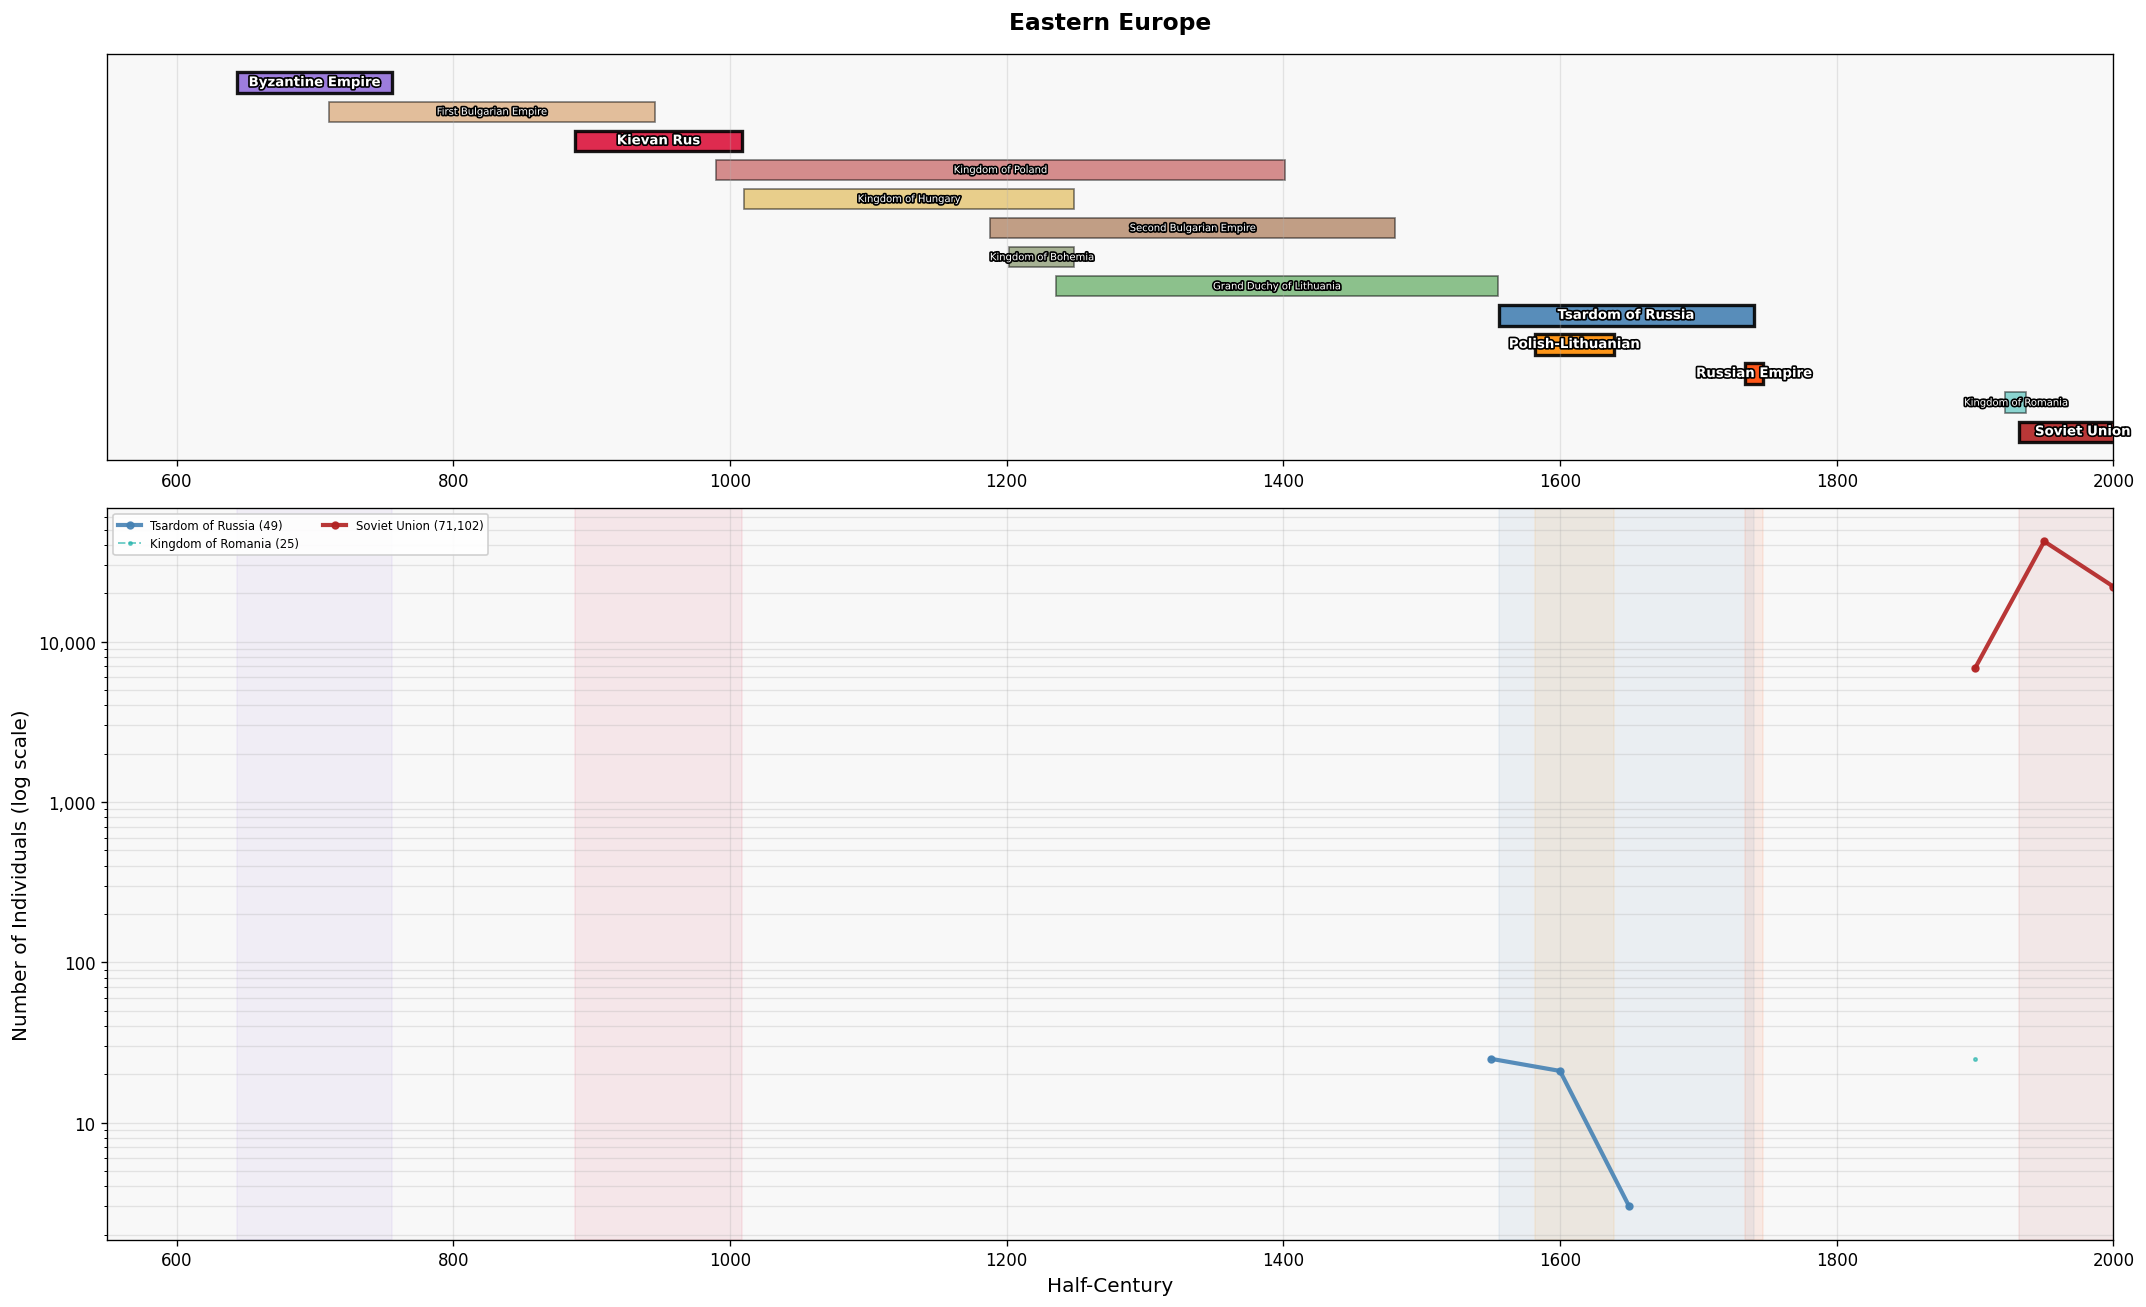

In [6]:
plot_timeline_and_lines(ee_data, 'Eastern Europe', (550, 2000), save_name='02_eastern_europe.png')

---
## 3. Arab & Islamic World

In [7]:
arab_islamic = [
    (379,  'Rashidun Caliphate',  '#2E8B57', True),
    (388,  'Umayyad Caliphate',  '#DAA520', True),
    (419,  'Abbasid Caliphate',  '#FF8C00', True),
    (436,  'Idrisids',           '#CD853F', False),
    (489,  'Samanid Empire',     '#6495ED', False),
    (510,  'Fatimid Caliphate',  '#9370DB', False),
    (544,  'Buyid Dynasty',      '#708090', False),
    (560,  'Ghaznavid Empire',   '#CD853F', False),
    (624,  'Great Seljuk Empire','#B22222', True),
    (638,  'Almoravid Dynasty',  '#556B2F', False),
    (693,  'Almohad Caliphate',  '#228B22', False),
    (709,  'Ayyubid Sultanate',  '#4682B4', False),
    (764,  'Mamluk Sultanate',   '#8B4513', False),
    (903,  'Timurid Empire',     '#DC143C', False),
    (842,  'Ottoman Empire',     '#FF4500', True),
    (993,  'Safavid Dynasty',    '#4169E1', True),
    (1165, 'Qajar Dynasty',      '#FFD700', False),
]
ai_data = load_region_data(conn, arab_islamic)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Rashidun Caliphate             638 CE - 1394 CE            10       4
* Umayyad Caliphate              674 CE - 1293 CE             1       1


* Abbasid Caliphate              755 CE - 1870 CE         5,318      21
  Idrisids                       800 CE - 910 CE            16       2
  Samanid Empire                 896 CE - 1002 CE            11       2
  Fatimid Caliphate              911 CE - 925 CE             0       0
  Buyid Dynasty                  947 CE - 1491 CE             0       0
  Ghaznavid Empire               990 CE - 1249 CE             0       0
* Great Seljuk Empire           1056 CE - 1201 CE             0       0
  Almoravid Dynasty             1066 CE - 1084 CE             0       0
  Almohad Caliphate             1152 CE - 1304 CE             0       0
  Ayyubid Sultanate             1188 CE - 1332 CE           451       4
  Mamluk Sultanate              1250 CE - 1384 CE             0       0
  Timurid Empire                1375 CE - 1384 CE             0       0
* Ottoman Empire                1314 CE - 1858 CE            96      12
* Safavid Dynasty               1507 CE - 1581 CE             0   

  Saved: dynasty_plots/03_arab_islamic.png


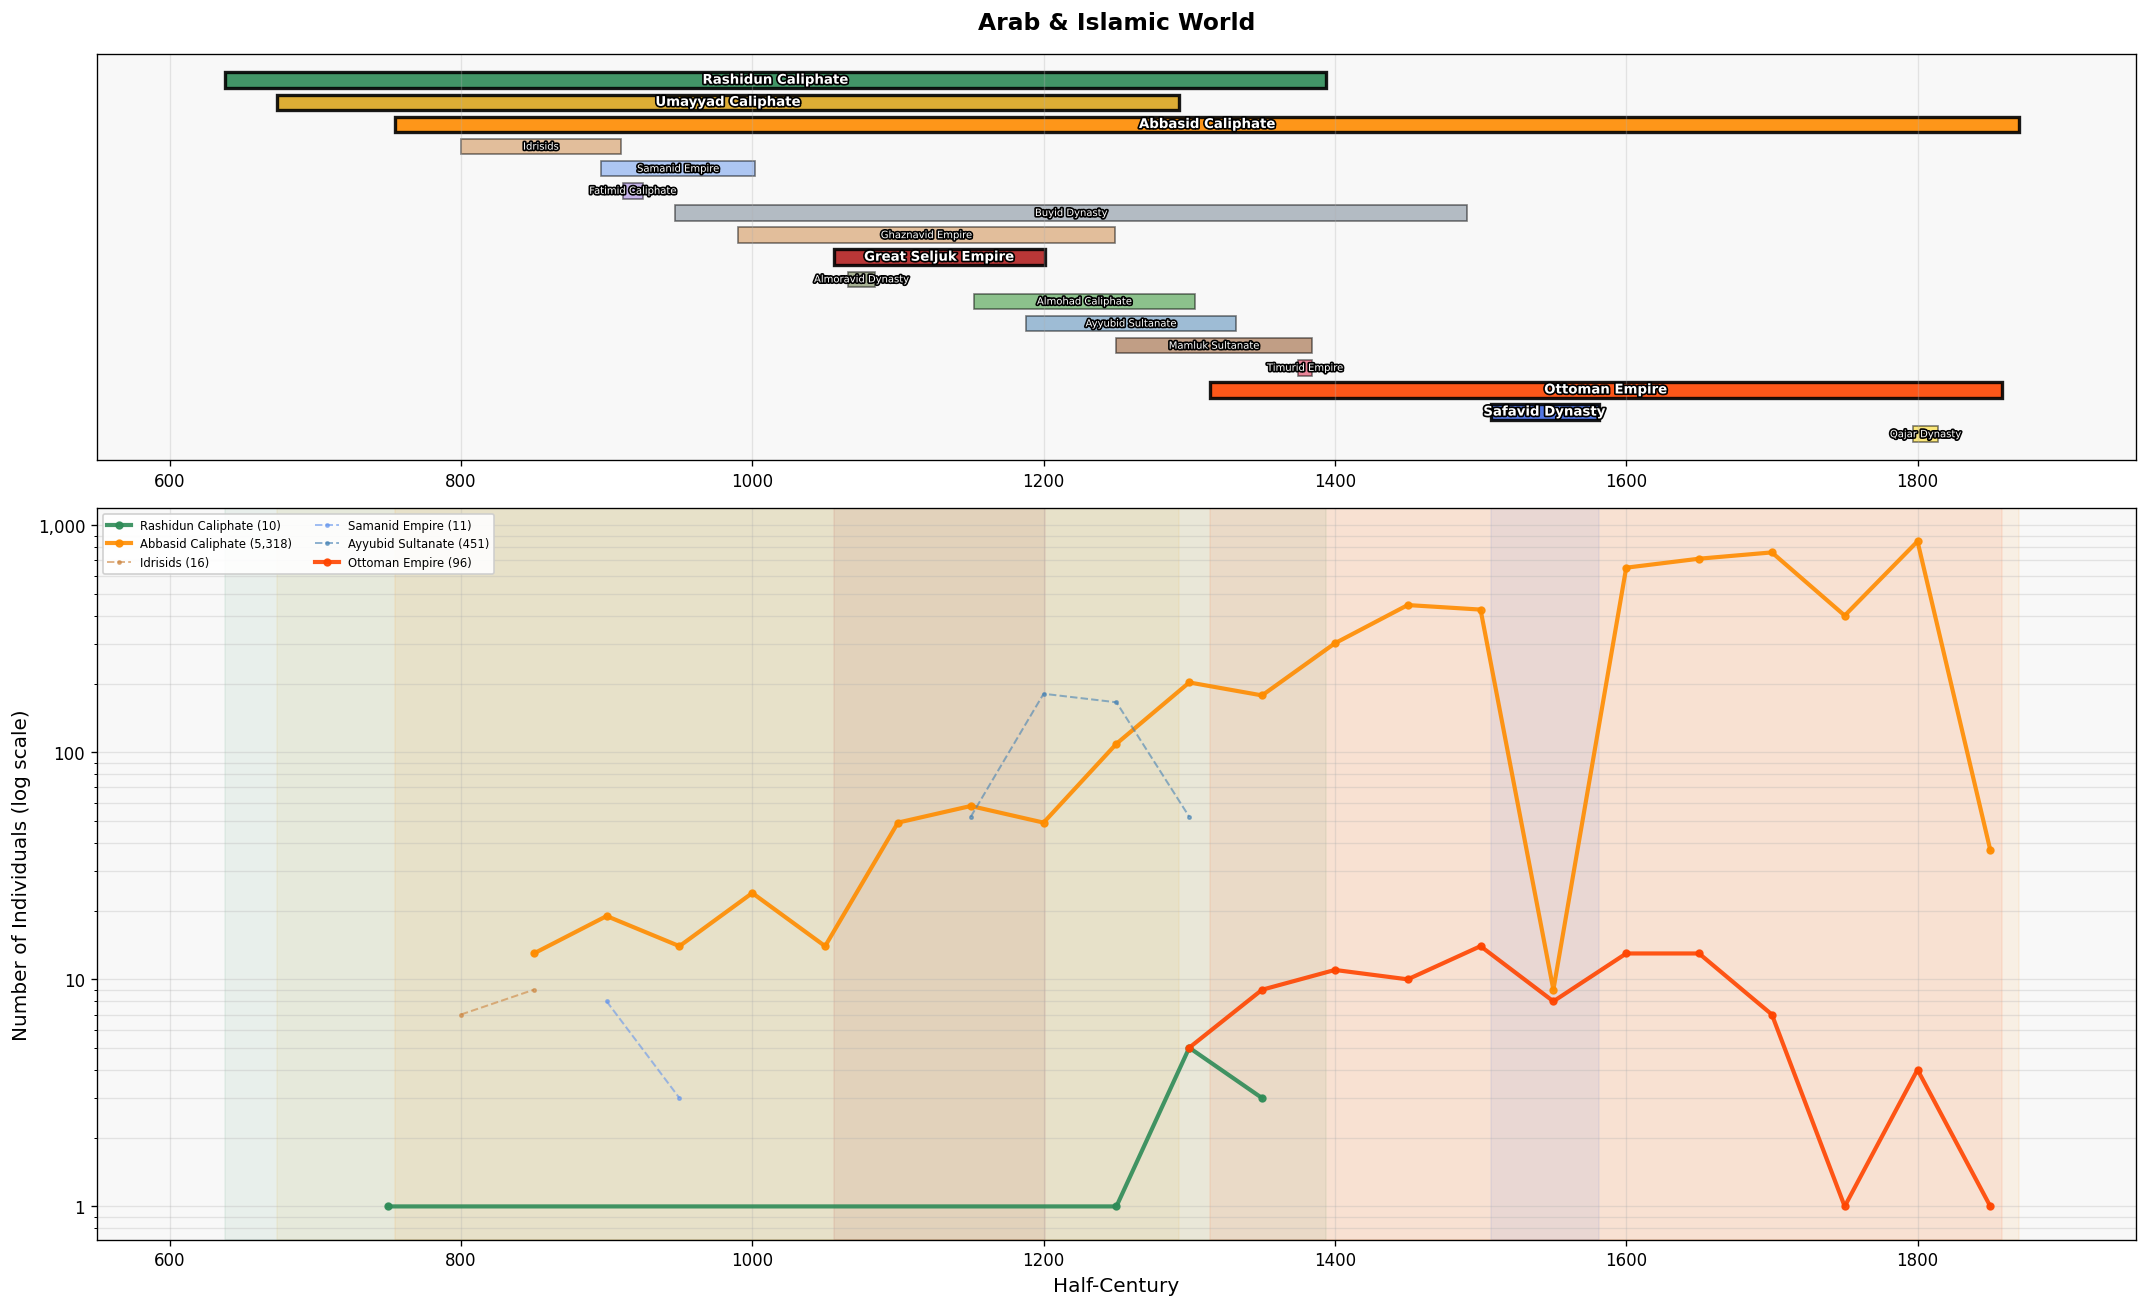

In [8]:
plot_timeline_and_lines(ai_data, 'Arab & Islamic World', (550, 1950), save_name='03_arab_islamic.png')

---
## 4. Mesopotamia & Ancient Persia

In [9]:
mesopotamia = [
    (1,    'Sumerian City-States','#8B4513', True),
    (6,    'Akkadian Empire',    '#DAA520', True),
    (13,   'Babylonia',          '#DC143C', True),
    (11,   'Assyria',            '#B22222', True),
    (31,   'Neo-Assyrian Empire','#FF8C00', True),
    (73,   'Neo-Babylonian',     '#4169E1', True),
    (89,   'Achaemenid Empire',  '#FF4500', True),
    (125,  'Seleucid Empire',    '#9370DB', False),
    (150,  'Parthian Empire',    '#228B22', False),
    (229,  'Sasanian Empire',    '#8B0000', True),
]
meso_data = load_region_data(conn, mesopotamia)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Sumerian City-States          3400 BCE - 1761 BCE            17       7
* Akkadian Empire               2300 BCE - 2101 BCE             9       5
* Babylonia                     1800 BCE - 601 BCE            28      12
* Assyria                       1800 BCE - 901 BCE            35      12
* Neo-Assyrian Empire           1000 BCE - 701 BCE            11       4
* Neo-Babylonian                600 BCE - 501 BCE             0       0
* Achaemenid Empire             600 BCE - 501 BCE             0       0
  Seleucid Empire               307 BCE - 165 BCE             0       0
  Parthian Empire               212 BCE - 42 CE              3       3
* Sasanian Empire                260 CE - 554 CE             0       0


  Saved: dynasty_plots/04_mesopotamia_persia.png


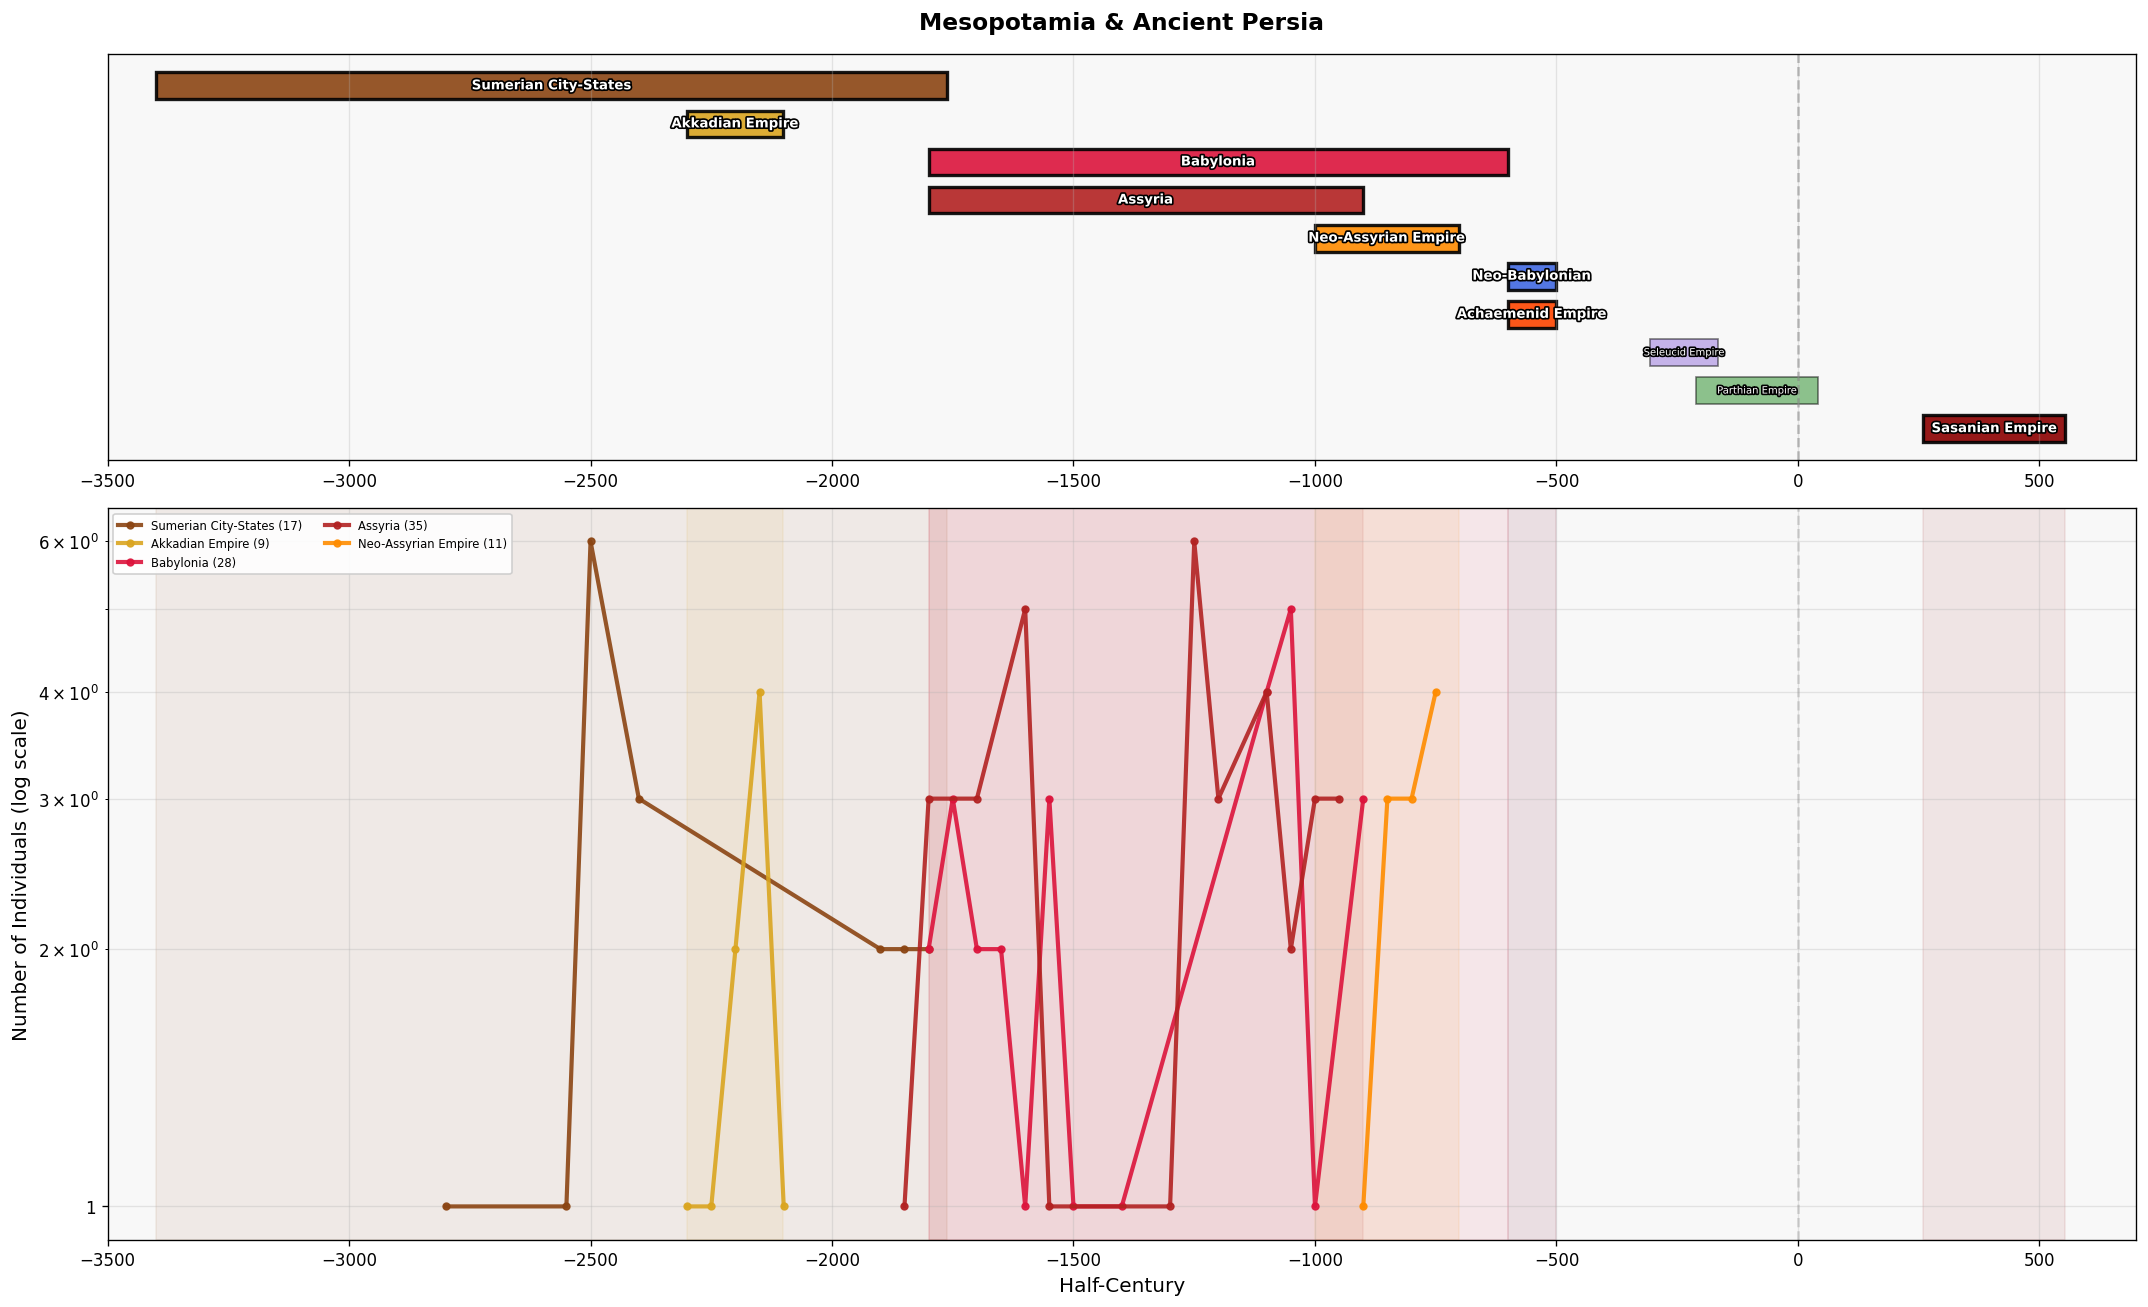

In [10]:
plot_timeline_and_lines(meso_data, 'Mesopotamia & Ancient Persia', (-3500, 700), save_name='04_mesopotamia_persia.png')

---
## 5. Indian World

In [11]:
indian = [
    (124,  'Maurya Empire',       '#FF8C00', True),
    (213,  'Kushan Empire',       '#8B4513', False),
    (250,  'Gupta Empire',        '#DAA520', True),
    (424,  'Rashtrakuta Dynasty', '#708090', False),
    (458,  'Chola Empire',        '#B22222', False),
    (673,  'Hoysala Kingdom',     '#556B2F', False),
    (746,  'Delhi Sultanate',     '#4169E1', True),
    (877,  'Vijayanagara Empire', '#228B22', True),
    (988,  'Mughal Empire',       '#DC143C', True),
    (1038, 'Kingdom of Mysore',   '#20B2AA', False),
    (1096, 'Maratha Empire',      '#FF4500', False),
    (1182, 'Sikh Empire',         '#FFD700', False),
    (1330, 'British Raj',         '#4682B4', True),
]
india_data = load_region_data(conn, indian)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Maurya Empire                 318 BCE - 316 BCE             0       0
  Kushan Empire                   60 CE - 237 CE             2       2
* Gupta Empire                   347 CE - 655 CE             0       0
  Rashtrakuta Dynasty            768 CE - 1065 CE             0       0
  Chola Empire                   850 CE - 1546 CE             3       3
  Hoysala Kingdom               1139 CE - 1304 CE             0       0
* Delhi Sultanate               1216 CE - 1325 CE             1       1
* Vijayanagara Empire           1344 CE - 1515 CE             3       2
* Mughal Empire                 1502 CE - 1823 CE           296       8
  Kingdom of Mysore             1572 CE - 1775 CE            67       5
  Maratha Empire                1702 CE - 1897 CE            41       5
  Sikh Empire                   1803 CE - 1806 CE             2     

* British Raj                   1868 CE - 2024 CE        26,246       5


  Saved: dynasty_plots/05_indian_world.png


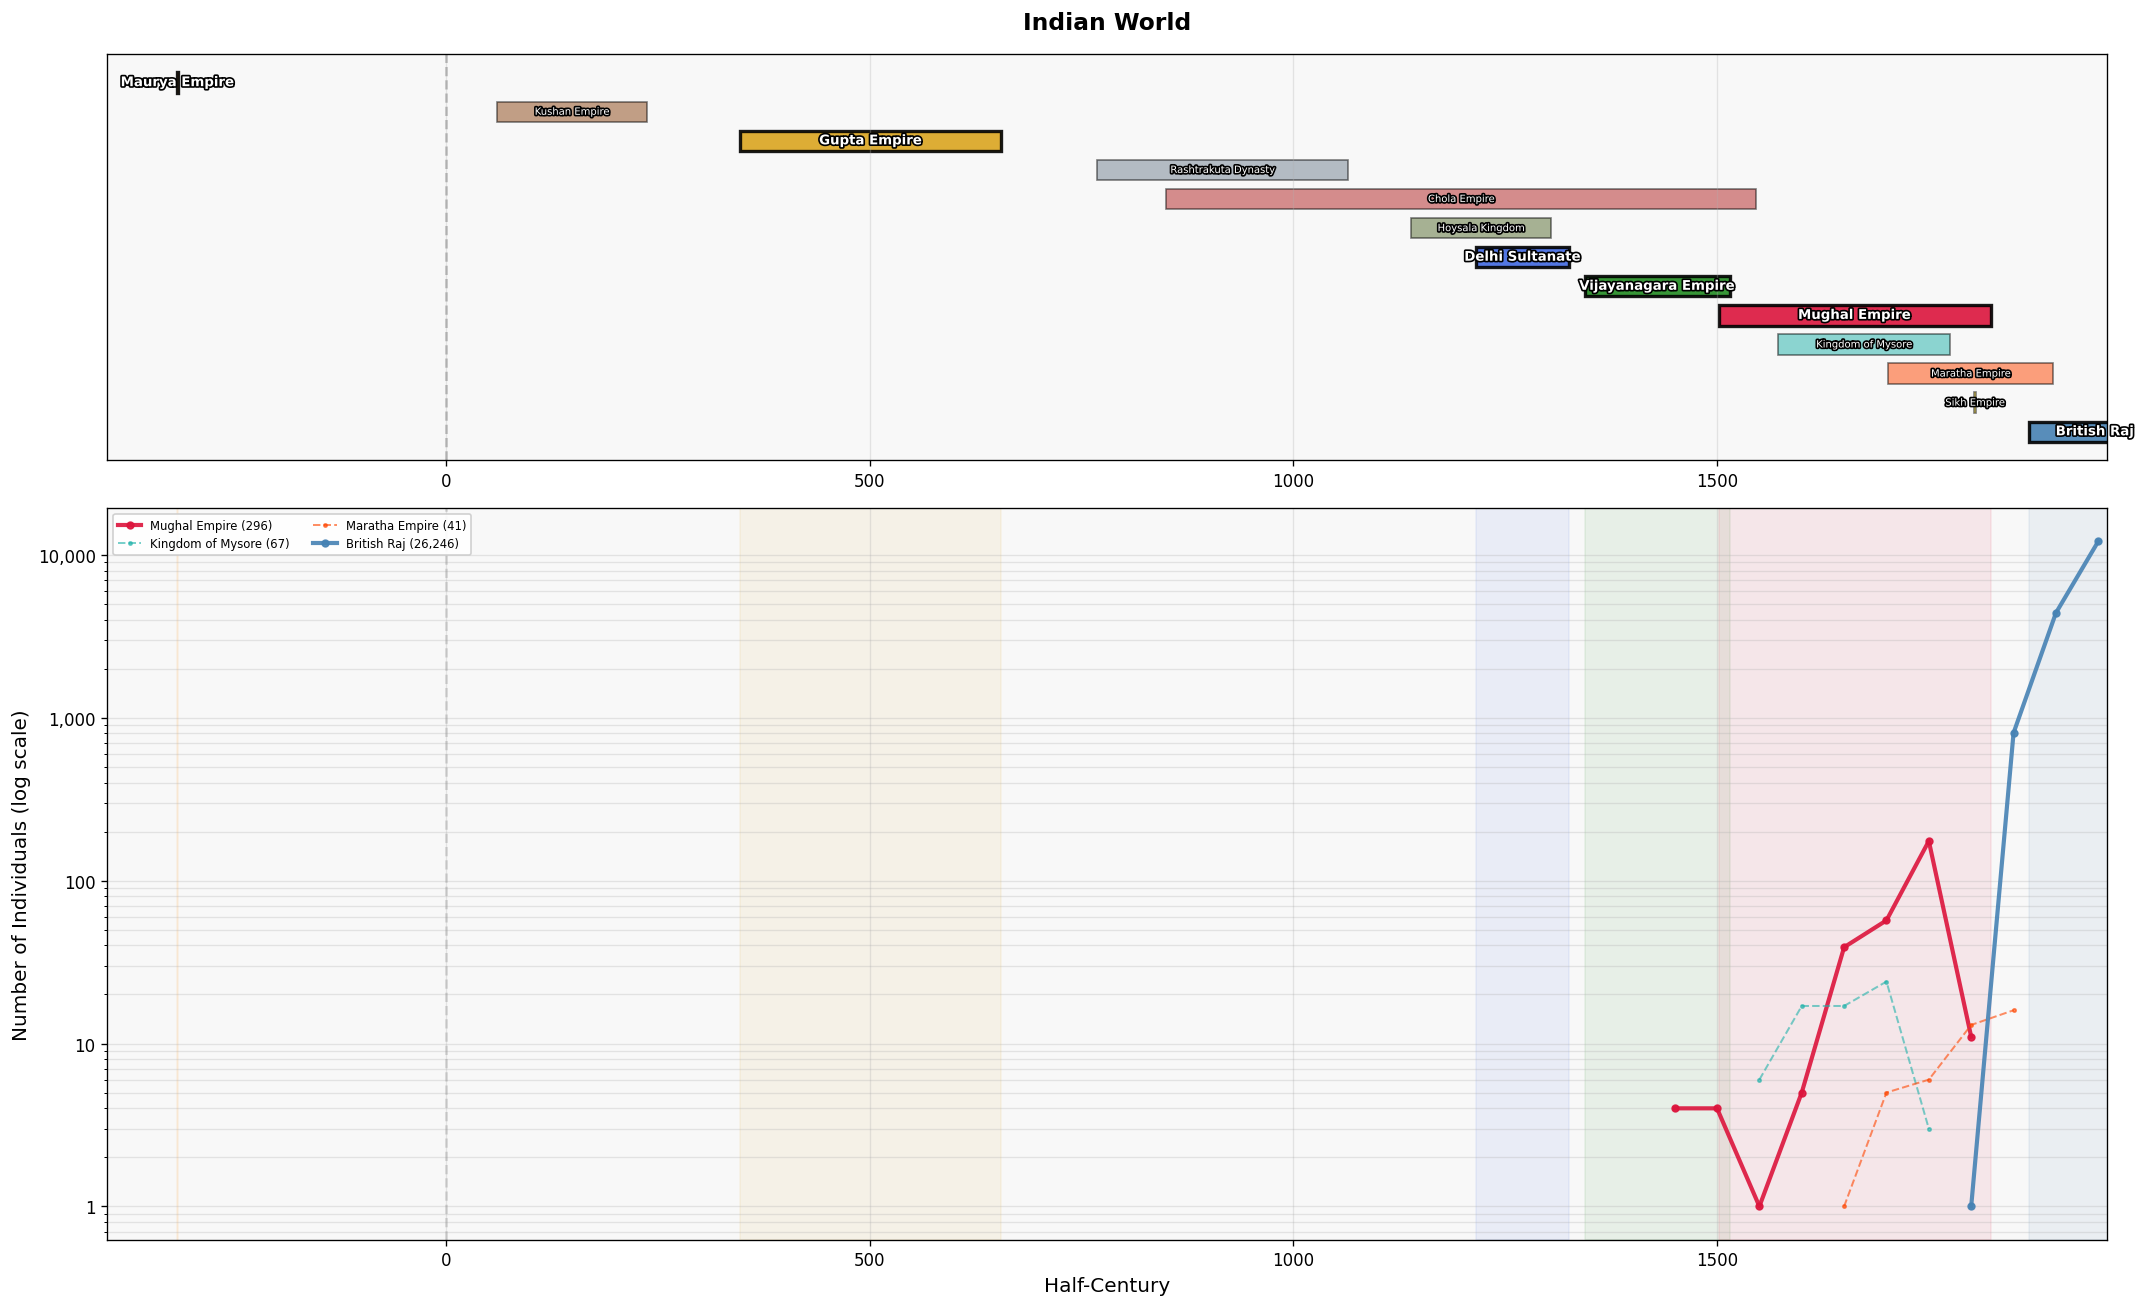

In [12]:
plot_timeline_and_lines(india_data, 'Indian World', (-400, 1960), save_name='05_indian_world.png')

---
## 6. East Asia (Japan & Korea)

In [13]:
east_asia = [
    (206,  'Goguryeo',            '#8B4513', False),
    (265,  'Silla',               '#CD853F', False),
    (257,  'Baekje',              '#556B2F', False),
    (330,  'Yamato',              '#DC143C', True),
    (397,  'Unified Silla',       '#DAA520', False),
    (530,  'Goryeo',              '#4169E1', True),
    (716,  'Kamakura Shogunate',  '#B22222', False),
    (734,  'Mongol Empire',       '#FF8C00', True),
    (875,  'Ashikaga Shogunate',  '#228B22', False),
    (916,  'Joseon',              '#9370DB', True),
    (969,  'Warring States Japan','#708090', False),
    (1054, 'Tokugawa Shogunate',  '#FF4500', True),
    (1340, 'Empire of Japan',     '#8B0000', True),
]
ea_data = load_region_data(conn, east_asia)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
  Goguryeo                         6 CE - 29 CE              4       1
  Silla                          387 CE - 409 CE            30       3
  Baekje                         358 CE - 509 CE             1       1
* Yamato                         546 CE - 601 CE             1       1


  Unified Silla                  705 CE - 1796 CE         4,509      22
* Goryeo                         936 CE - 1071 CE            67       4
  Kamakura Shogunate            1202 CE - 1452 CE             0       0
* Mongol Empire                 1206 CE - 1501 CE             0       0
  Ashikaga Shogunate            1344 CE - 1571 CE            18       4
* Joseon                        1395 CE - 1481 CE             5       3
  Warring States Japan          1468 CE - 1601 CE           362       4
* Tokugawa Shogunate            1609 CE - 1876 CE             2       2
* Empire of Japan               1885 CE - 1960 CE             0       0


  Saved: dynasty_plots/06_east_asia.png


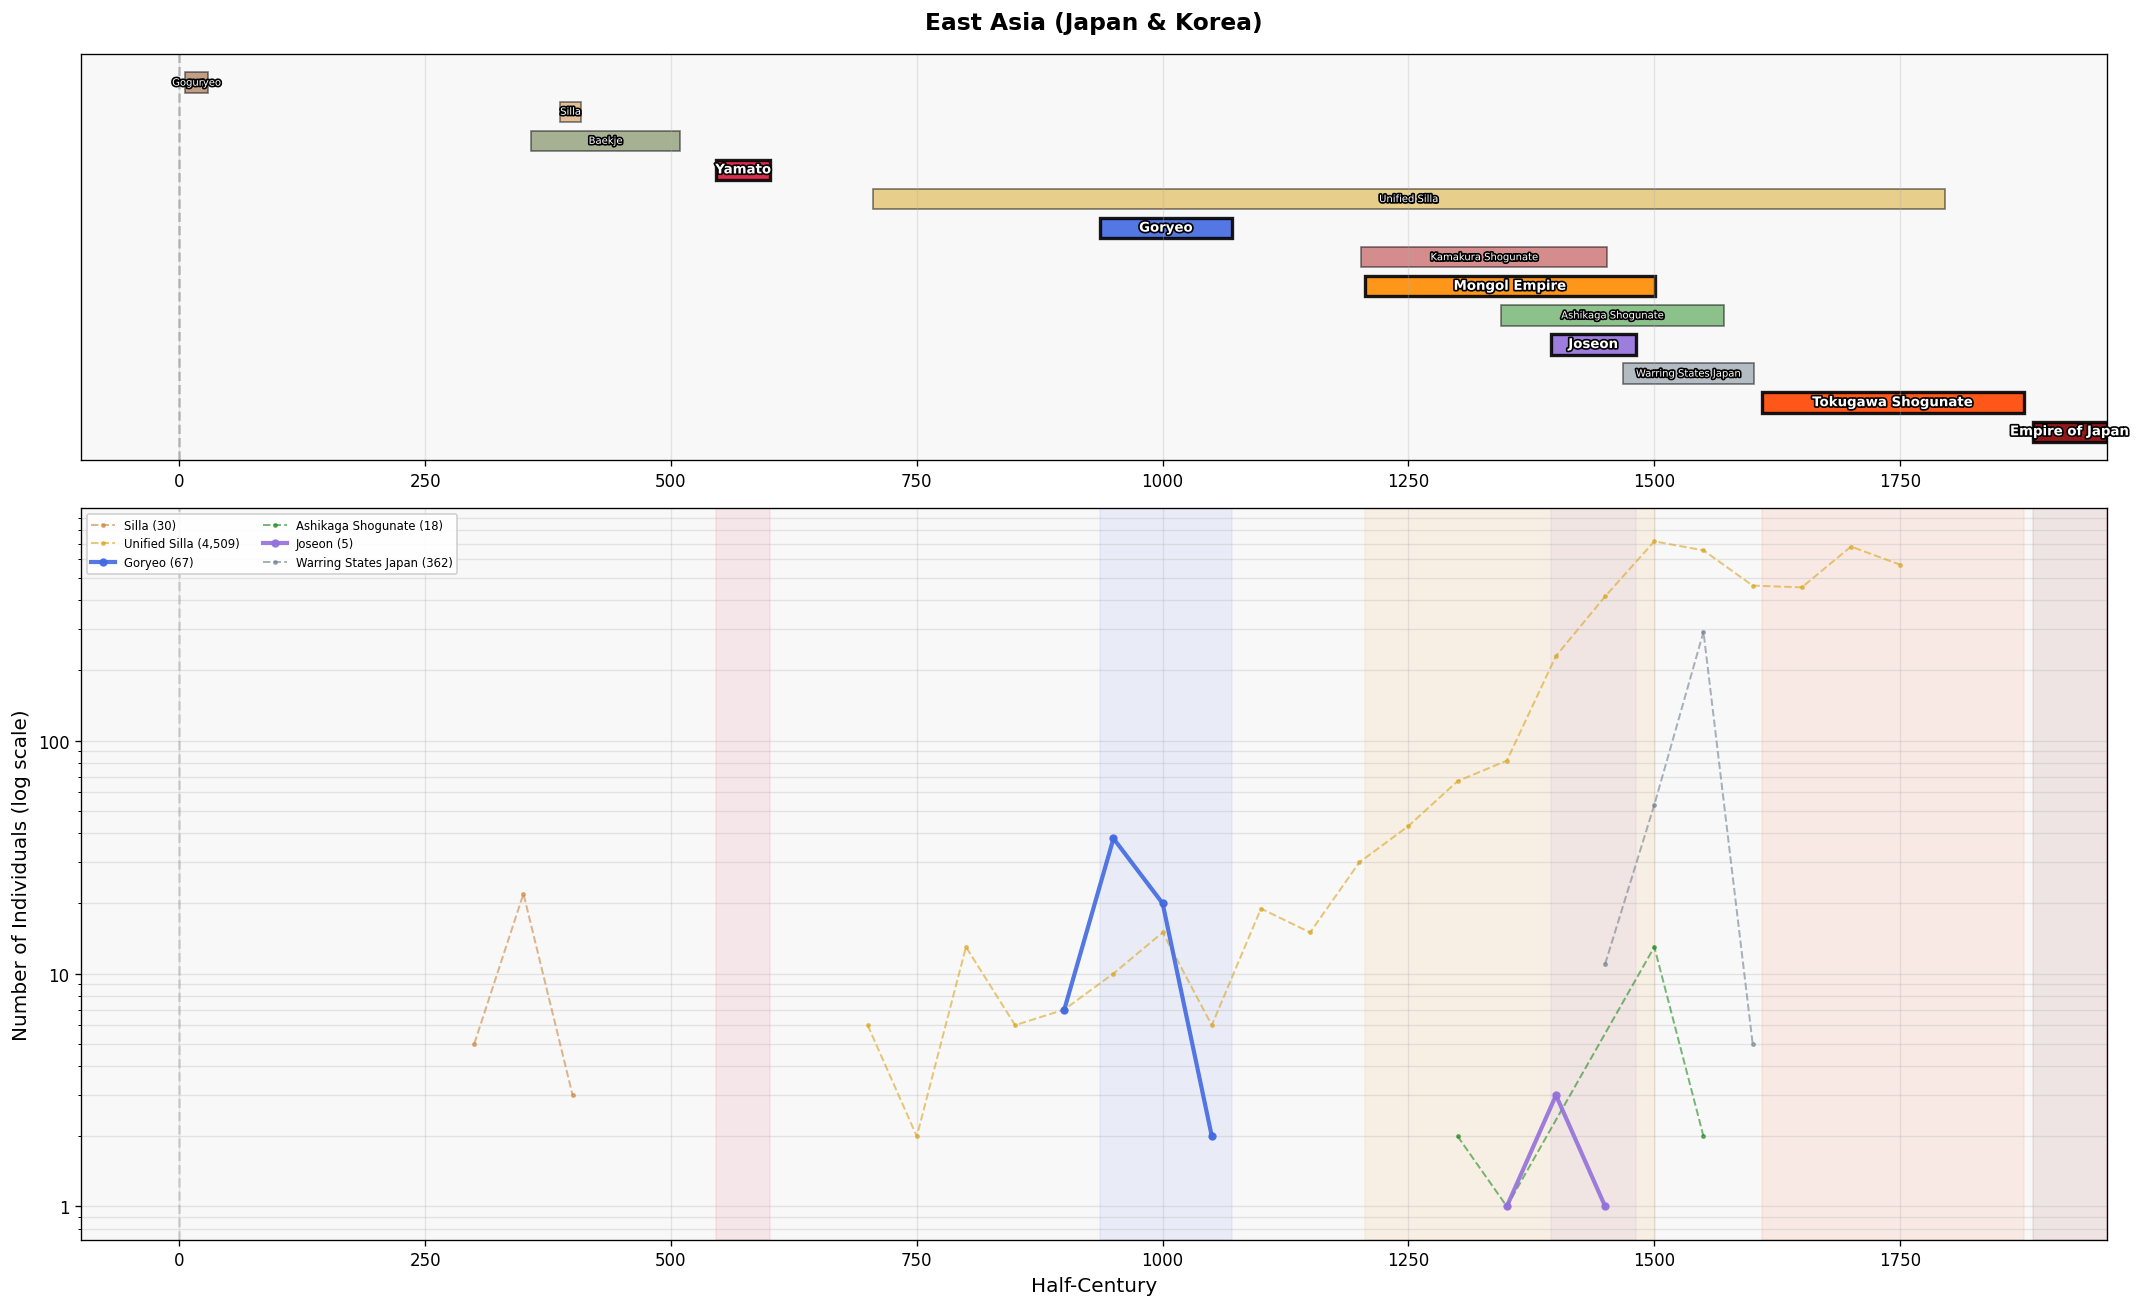

In [14]:
plot_timeline_and_lines(ea_data, 'East Asia (Japan & Korea)', (-100, 1960), save_name='06_east_asia.png')

---
## 7. Southeast Asia

In [15]:
southeast_asia = [
    (223,  'Champa',              '#CD853F', False),
    (394,  'Srivijaya',           '#20B2AA', False),
    (440,  'Khmer Empire',        '#DC143C', True),
    (456,  'Pagan Kingdom',       '#DAA520', True),
    (766,  'Sukhothai Kingdom',   '#4169E1', False),
    (814,  'Majapahit',           '#228B22', True),
    (882,  'Ayutthaya Kingdom',   '#FF8C00', True),
    (897,  'Lan Xang',            '#9370DB', False),
    (885,  'Sultanate of Brunei', '#556B2F', False),
    (994,  'Toungoo Empire',      '#B22222', False),
    (1136, 'Konbaung Dynasty',    '#8B4513', False),
    (1163, 'Rattanakosin',        '#FF4500', True),
    (1185, 'Dutch East Indies',   '#FF7F50', False),
    (1418, 'Kingdom of Thailand', '#FFD700', True),
    (1445, 'Republic of Indonesia','#DC143C', True),
    (1451, 'Republic of Philippines','#4169E1', True),
    (1516, 'Malaysia',            '#228B22', False),
]
sea_data = load_region_data(conn, southeast_asia)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
  Champa                         215 CE - 643 CE           151       8
  Srivijaya                      692 CE - 749 CE             4       1
* Khmer Empire                   814 CE - 839 CE             0       0
* Pagan Kingdom                  850 CE - 910 CE             0       0
  Sukhothai Kingdom             1250 CE - 1467 CE            48       3


* Majapahit                     1294 CE - 2024 CE        61,155      12
* Ayutthaya Kingdom             1363 CE - 1858 CE           108       9
  Lan Xang                      1375 CE - 1439 CE             7       2
  Sultanate of Brunei           1363 CE - 1414 CE             1       1
  Toungoo Empire                1507 CE - 1528 CE             0       0
  Konbaung Dynasty              1757 CE - 1768 CE             0       0
* Rattanakosin                  1796 CE - 1799 CE            82       1
  Dutch East Indies             1805 CE - 1915 CE            92       3
* Kingdom of Thailand           1941 CE - 1944 CE           249       1
* Republic of Indonesia         1948 CE - 2024 CE         3,229       3
* Republic of Philippines       1950 CE - 1990 CE         1,743       1
  Malaysia                      1967 CE - 2024 CE         2,001       2


  Saved: dynasty_plots/07_southeast_asia.png


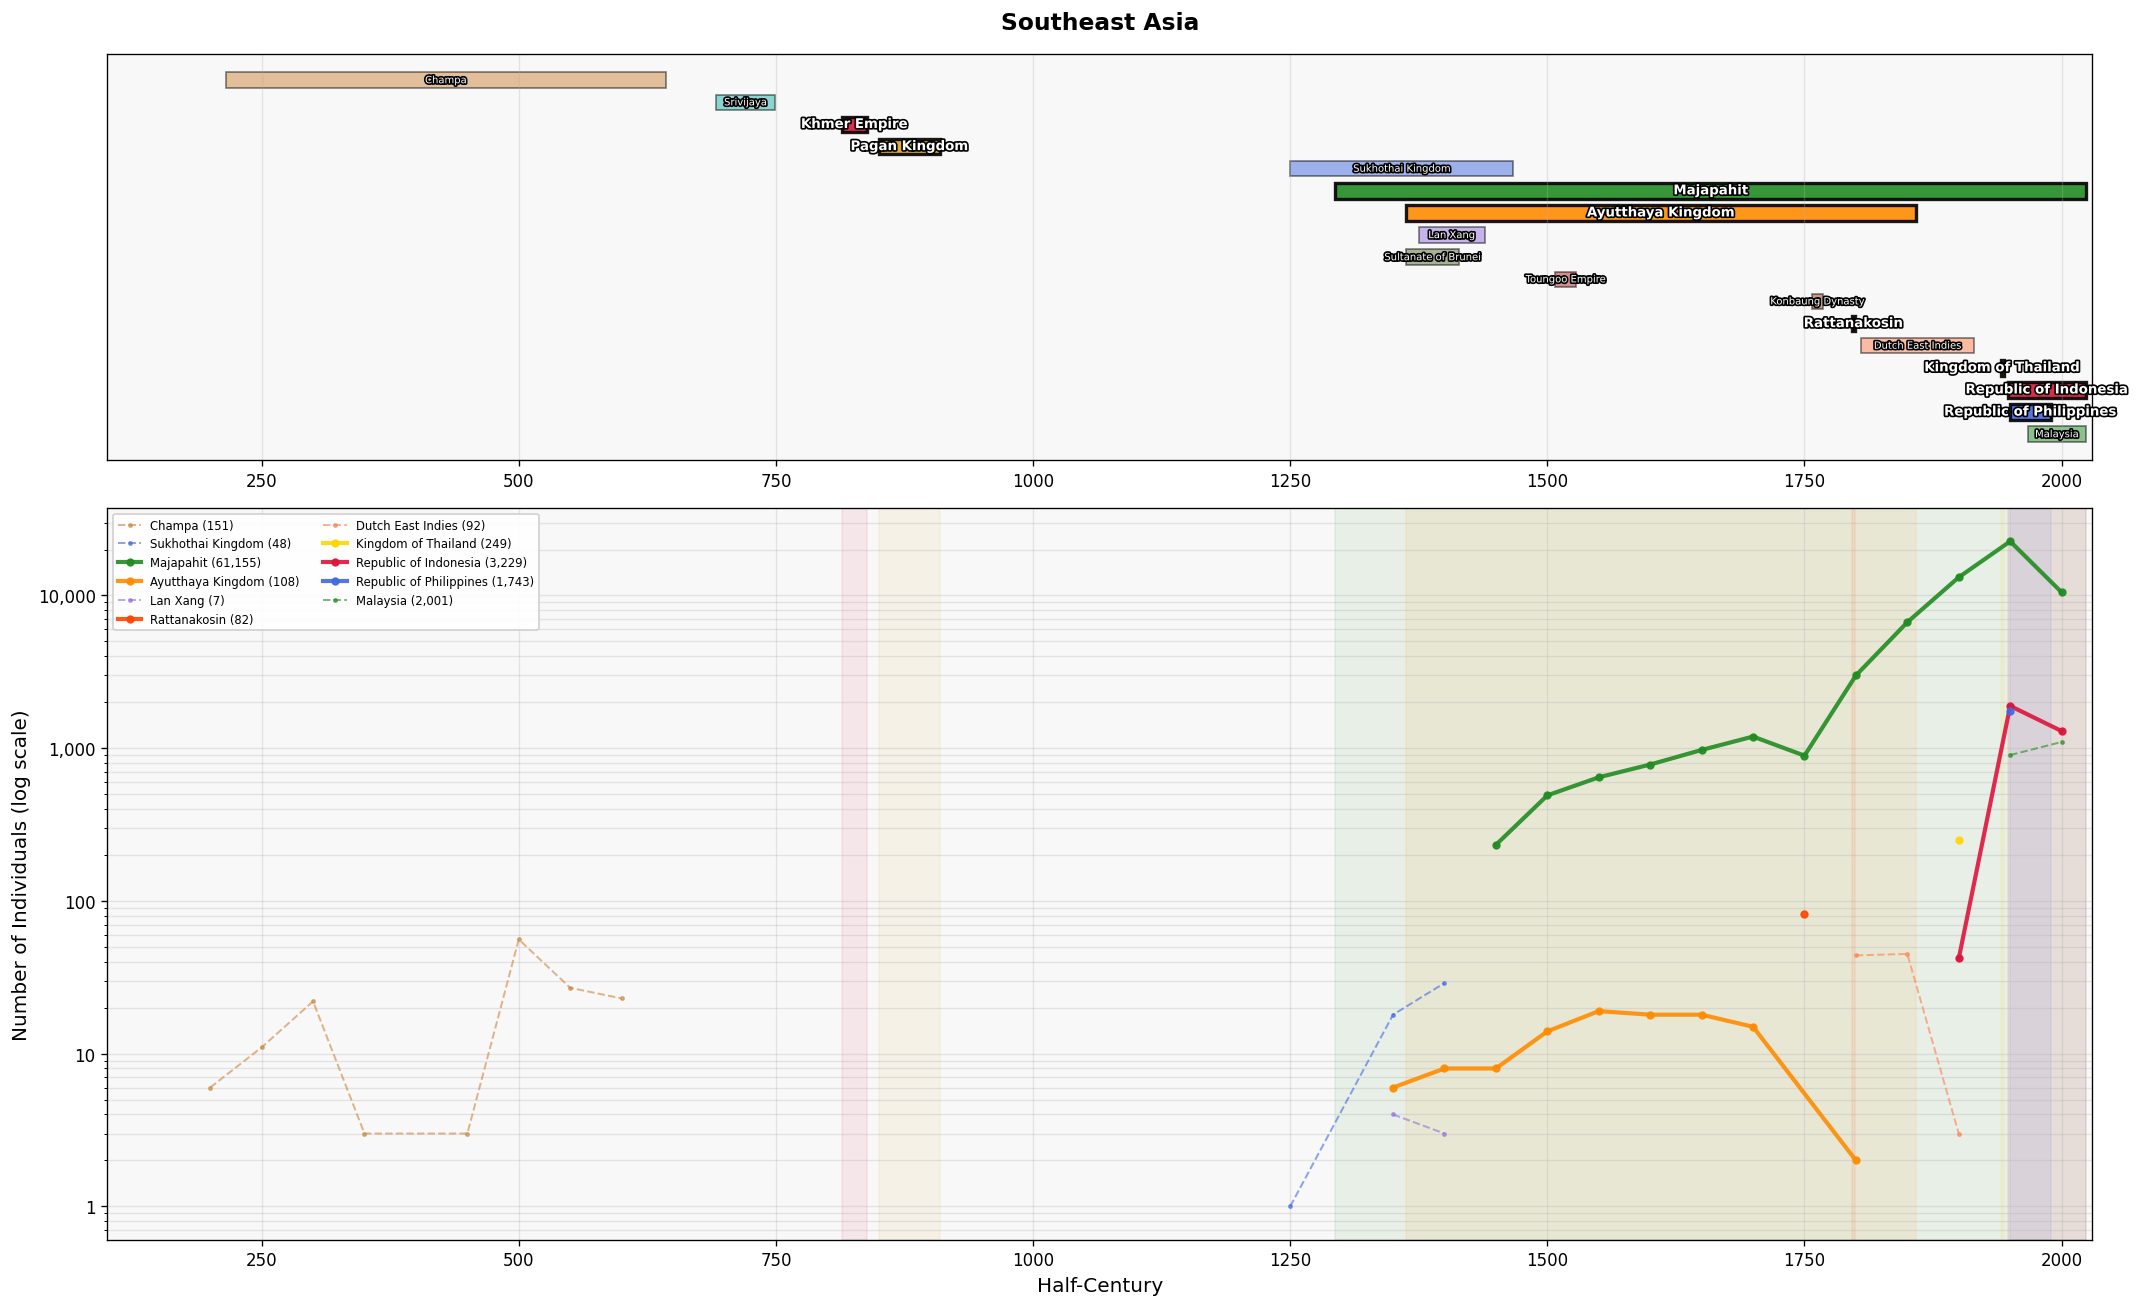

In [16]:
plot_timeline_and_lines(sea_data, 'Southeast Asia', (100, 2030), save_name='07_southeast_asia.png')

---
## 8. Africa

In [17]:
africa = [
    (3,    'Early Dynastic Egypt','#DAA520', False),
    (5,    'Old Kingdom Egypt',   '#CD853F', False),
    (10,   'Middle Kingdom Egypt','#B8860B', False),
    (23,   'New Kingdom Egypt',   '#FF8C00', True),
    (29,   'Kingdom of Kush',     '#8B4513', False),
    (115,  'Ptolemaic Kingdom',   '#4169E1', False),
    (205,  'Kingdom of Axum',     '#228B22', True),
    (757,  'Mali Empire',         '#DC143C', True),
    (791,  'Ethiopian Empire',    '#2E8B57', True),
    (941,  'Kingdom of Kongo',    '#9370DB', False),
    (961,  'Songhai Empire',      '#B22222', True),
    (1058, 'Oyo Empire',          '#FF4500', False),
    (1104, 'Ashanti Empire',      '#FFD700', False),
    (1172, 'Merina Kingdom',      '#20B2AA', False),
    (1197, 'Sokoto Caliphate',    '#4682B4', False),
]
africa_data = load_region_data(conn, africa)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
  Early Dynastic Egypt          3000 BCE - 2501 BCE            36      12
  Old Kingdom Egypt             2500 BCE - 2201 BCE            35       6
  Middle Kingdom Egypt          2000 BCE - 1601 BCE            56       8
* New Kingdom Egypt             1500 BCE - 801 BCE           153      15
  Kingdom of Kush               1100 BCE - 801 BCE             4       4
  Ptolemaic Kingdom             331 BCE - 92 BCE             2       2
* Kingdom of Axum                  1 CE - 90 CE              1       1
* Mali Empire                   1236 CE - 1506 CE             2       2
* Ethiopian Empire              1279 CE - 1313 CE             0       0
  Kingdom of Kongo              1440 CE - 1571 CE            17       3
* Songhai Empire                1463 CE - 1608 CE             7       2
  Oyo Empire                    1619 CE - 1720 CE           

  Saved: dynasty_plots/08_africa.png


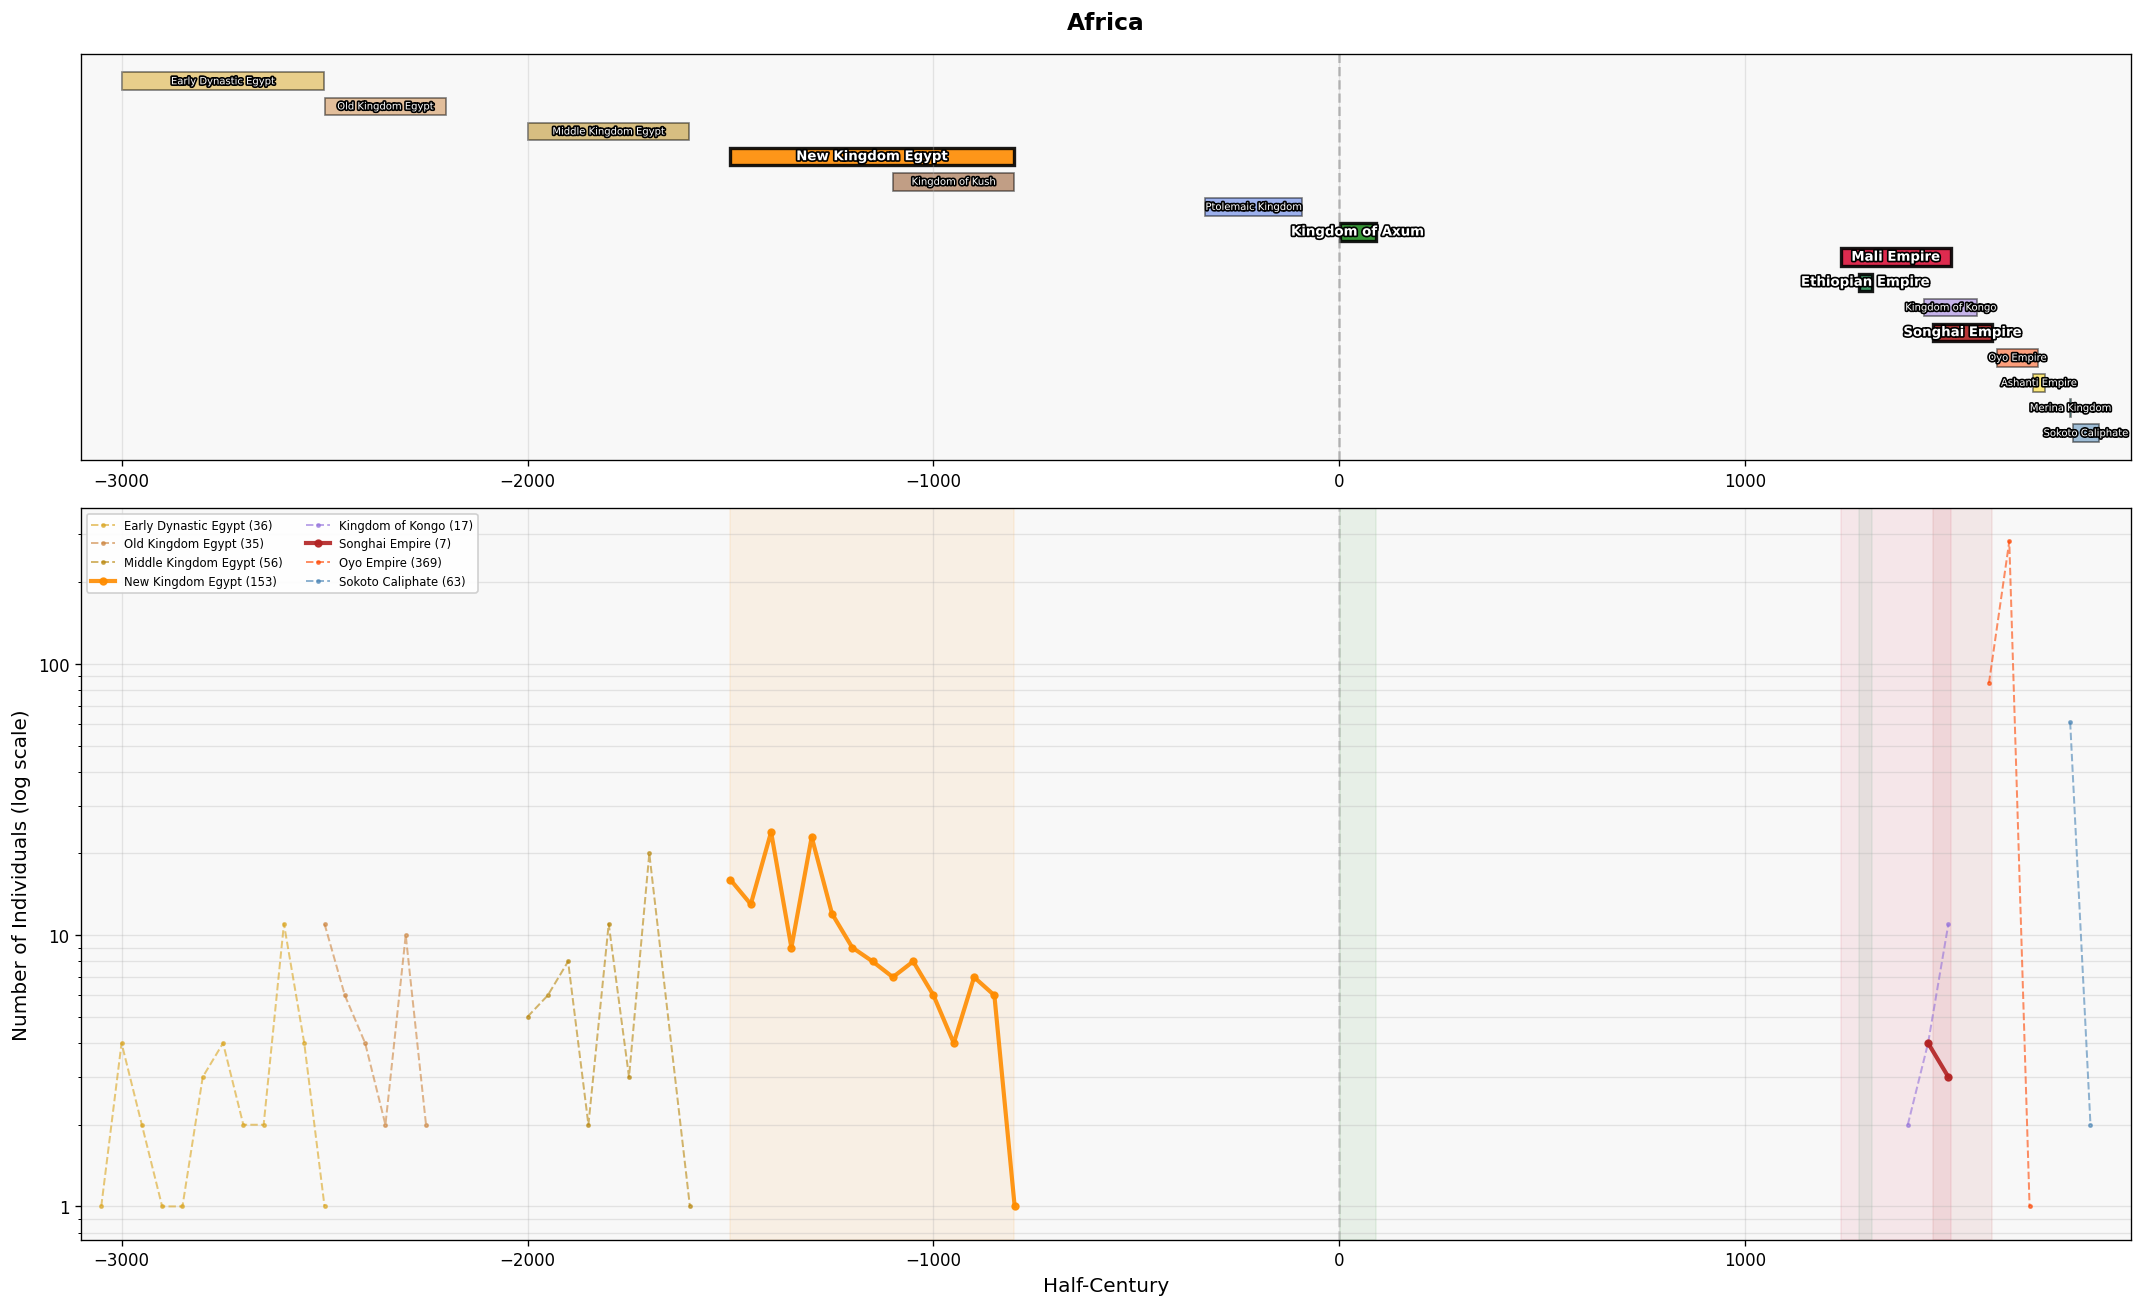

In [18]:
plot_timeline_and_lines(africa_data, 'Africa', (-3100, 1950), save_name='08_africa.png')

---
## 9. North America

In [19]:
north_america = [
    (149,  'Mayan City-States',   '#228B22', True),
    (938,  'Aztec Triple Alliance','#DC143C', True),
    (949,  'Haudenosaunee',       '#8B4513', False),
    (1057, 'New France',          '#4169E1', False),
    (1060, 'English Colonies',    '#2E8B57', False),
    (1273, 'Mexico (early)',      '#FF8C00', False),
    (1159, 'United States',       '#B22222', True),
    (1343, 'Mexico',              '#228B22', True),
    (1417, 'Canada',              '#FF4500', True),
    (1491, 'Cuba',                '#DAA520', False),
]
na_data = load_region_data(conn, north_america)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Mayan City-States             218 BCE - 209 BCE             0       0
* Aztec Triple Alliance         1429 CE - 1449 CE             0       0
  Haudenosaunee                 1450 CE - 1458 CE             0       0


  New France                    1612 CE - 1814 CE        11,092       5
  English Colonies              1619 CE - 1821 CE             0       0
  Mexico (early)                1834 CE - 1858 CE             7       2
* United States                 1792 CE - 1802 CE            26       3
* Mexico                        1890 CE - 2024 CE         3,865       3
* Canada                        1940 CE - 1944 CE           303       1


  Cuba                          1961 CE - 2024 CE         9,550       2


  Saved: dynasty_plots/09_north_america.png


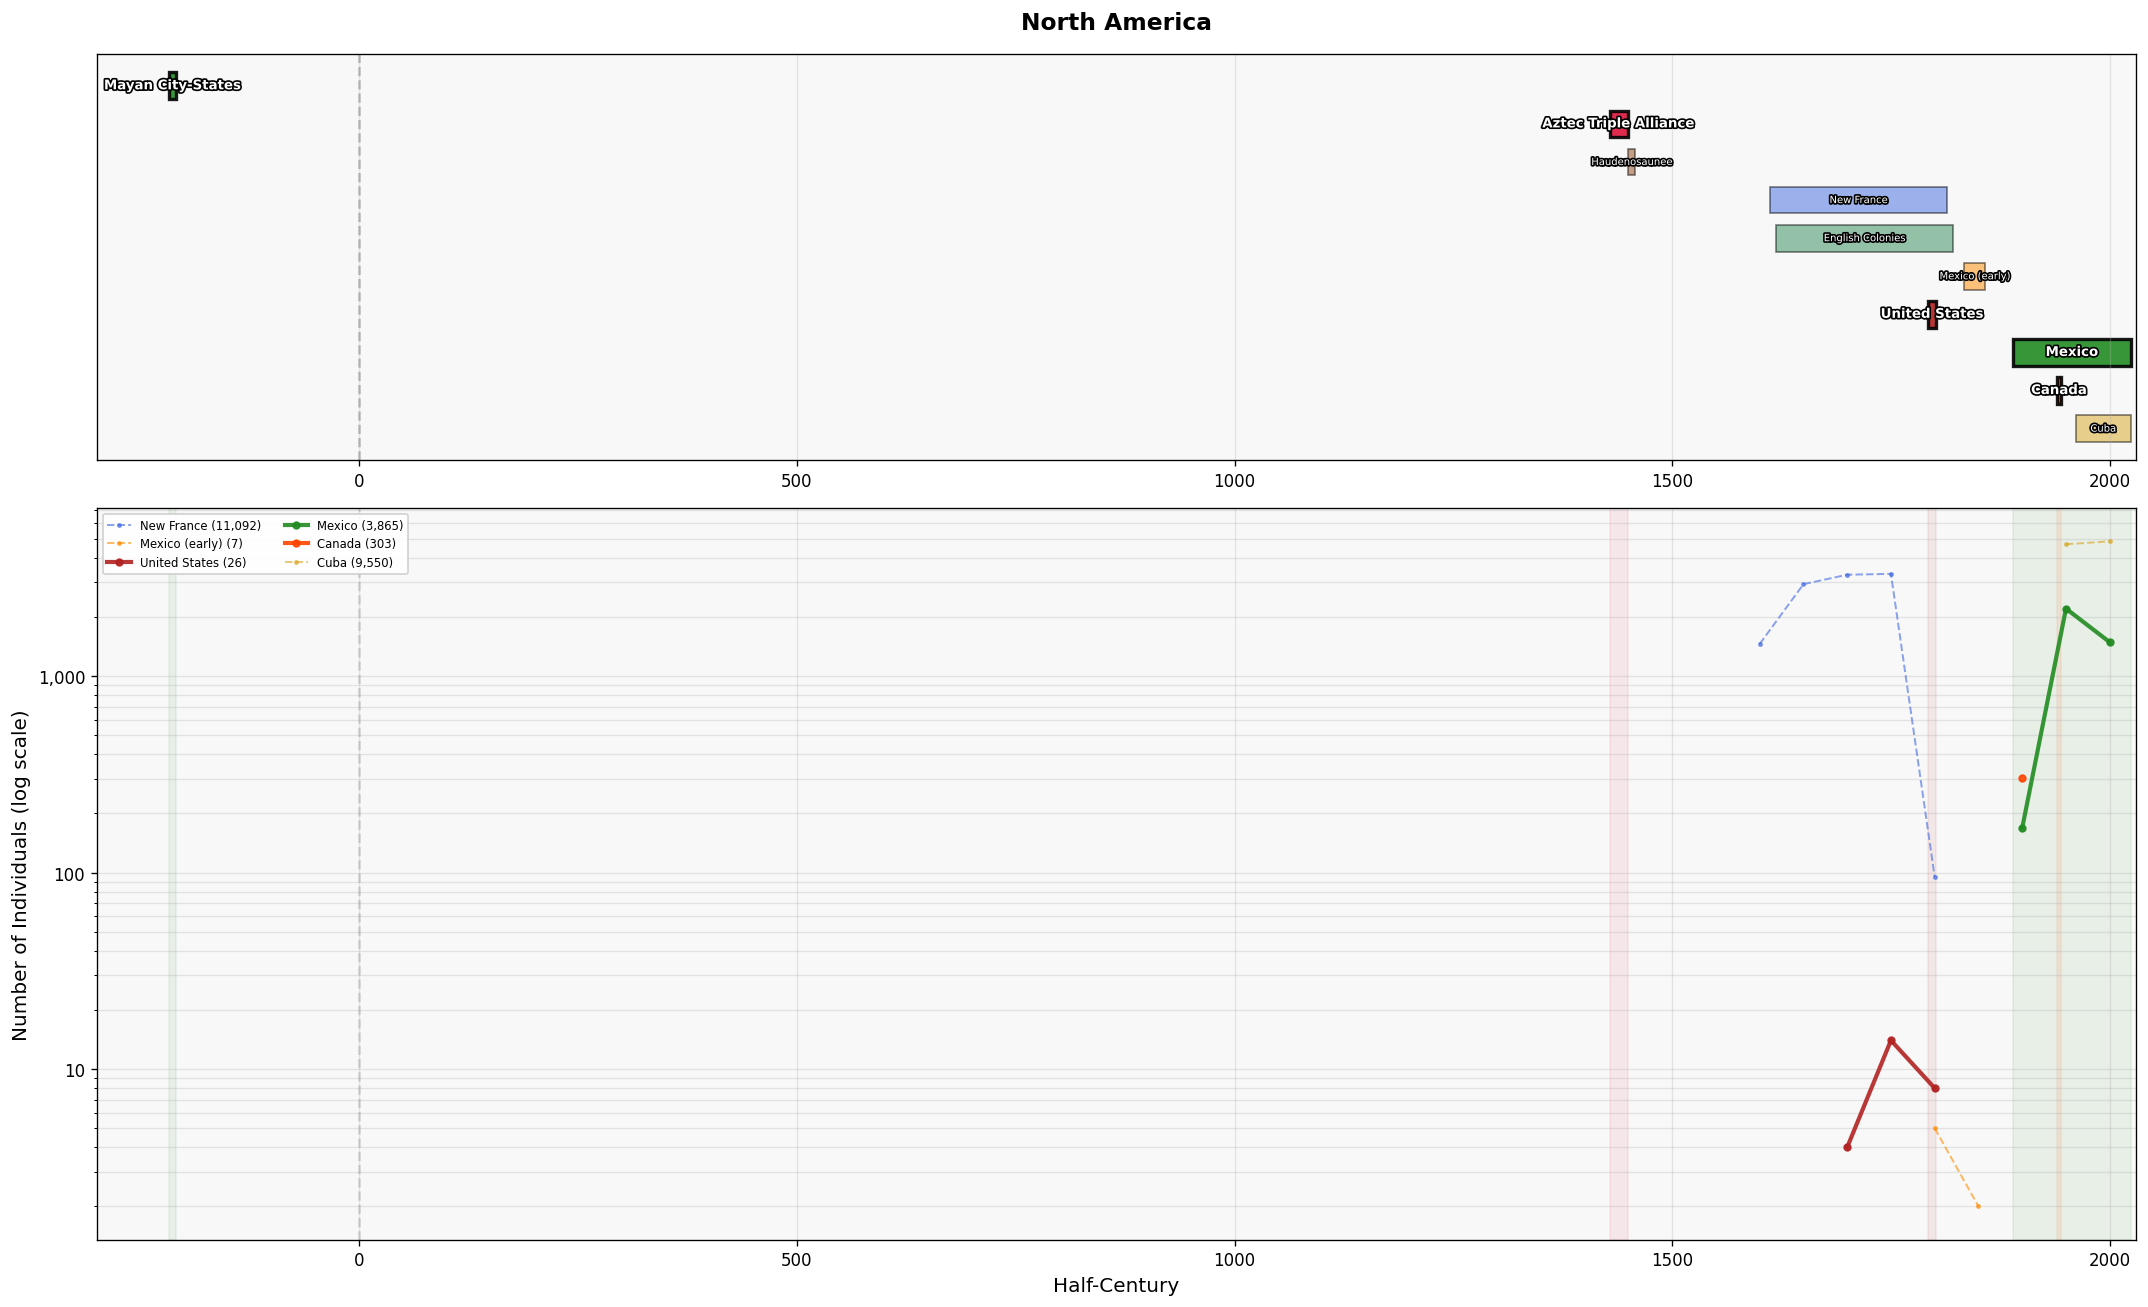

In [20]:
plot_timeline_and_lines(na_data, 'North America', (-300, 2030), save_name='09_north_america.png')

---
## 10. South America

In [21]:
south_america = [
    (940,  'Inca Empire',           '#FF8C00', True),
    (1266, 'Empire of Brazil',      '#228B22', True),
    (1267, 'Gran Colombia',         '#DC143C', True),
    (1234, 'Republic of Chile',     '#B22222', False),
    (1270, 'Republic of Peru',      '#DAA520', False),
    (1283, 'Venezuela',             '#4169E1', False),
    (1274, 'Bolivia',               '#8B4513', False),
    (1286, 'Argentine Confed.',     '#FF4500', False),
    (1278, 'Uruguay',               '#9370DB', False),
    (1285, 'Republic of Ecuador',   '#20B2AA', False),
    (1230, 'Paraguay',              '#556B2F', False),
    (1359, 'Brazilian Republic',    '#2E8B57', True),
    (1414, 'Argentine Republic',    '#CD853F', True),
]
sa_data = load_region_data(conn, south_america)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
* Inca Empire                   1431 CE - 1768 CE            45       4
* Empire of Brazil              1828 CE - 1858 CE            17       2


* Gran Colombia                 1828 CE - 2024 CE        15,326       5
  Republic of Chile             1815 CE - 1939 CE            46       3
  Republic of Peru              1830 CE - 1848 CE             0       0
  Venezuela                     1840 CE - 1841 CE             0       0


  Bolivia                       1834 CE - 2024 CE         3,725       5
  Argentine Confed.             1840 CE - 1910 CE             9       2
  Uruguay                       1836 CE - 1845 CE             0       0
  Republic of Ecuador           1840 CE - 2024 CE         1,688       5
  Paraguay                      1814 CE - 1870 CE           304       2


* Brazilian Republic            1912 CE - 2024 CE        16,835       3


* Argentine Republic            1938 CE - 2024 CE        13,318       3


  Saved: dynasty_plots/10_south_america.png


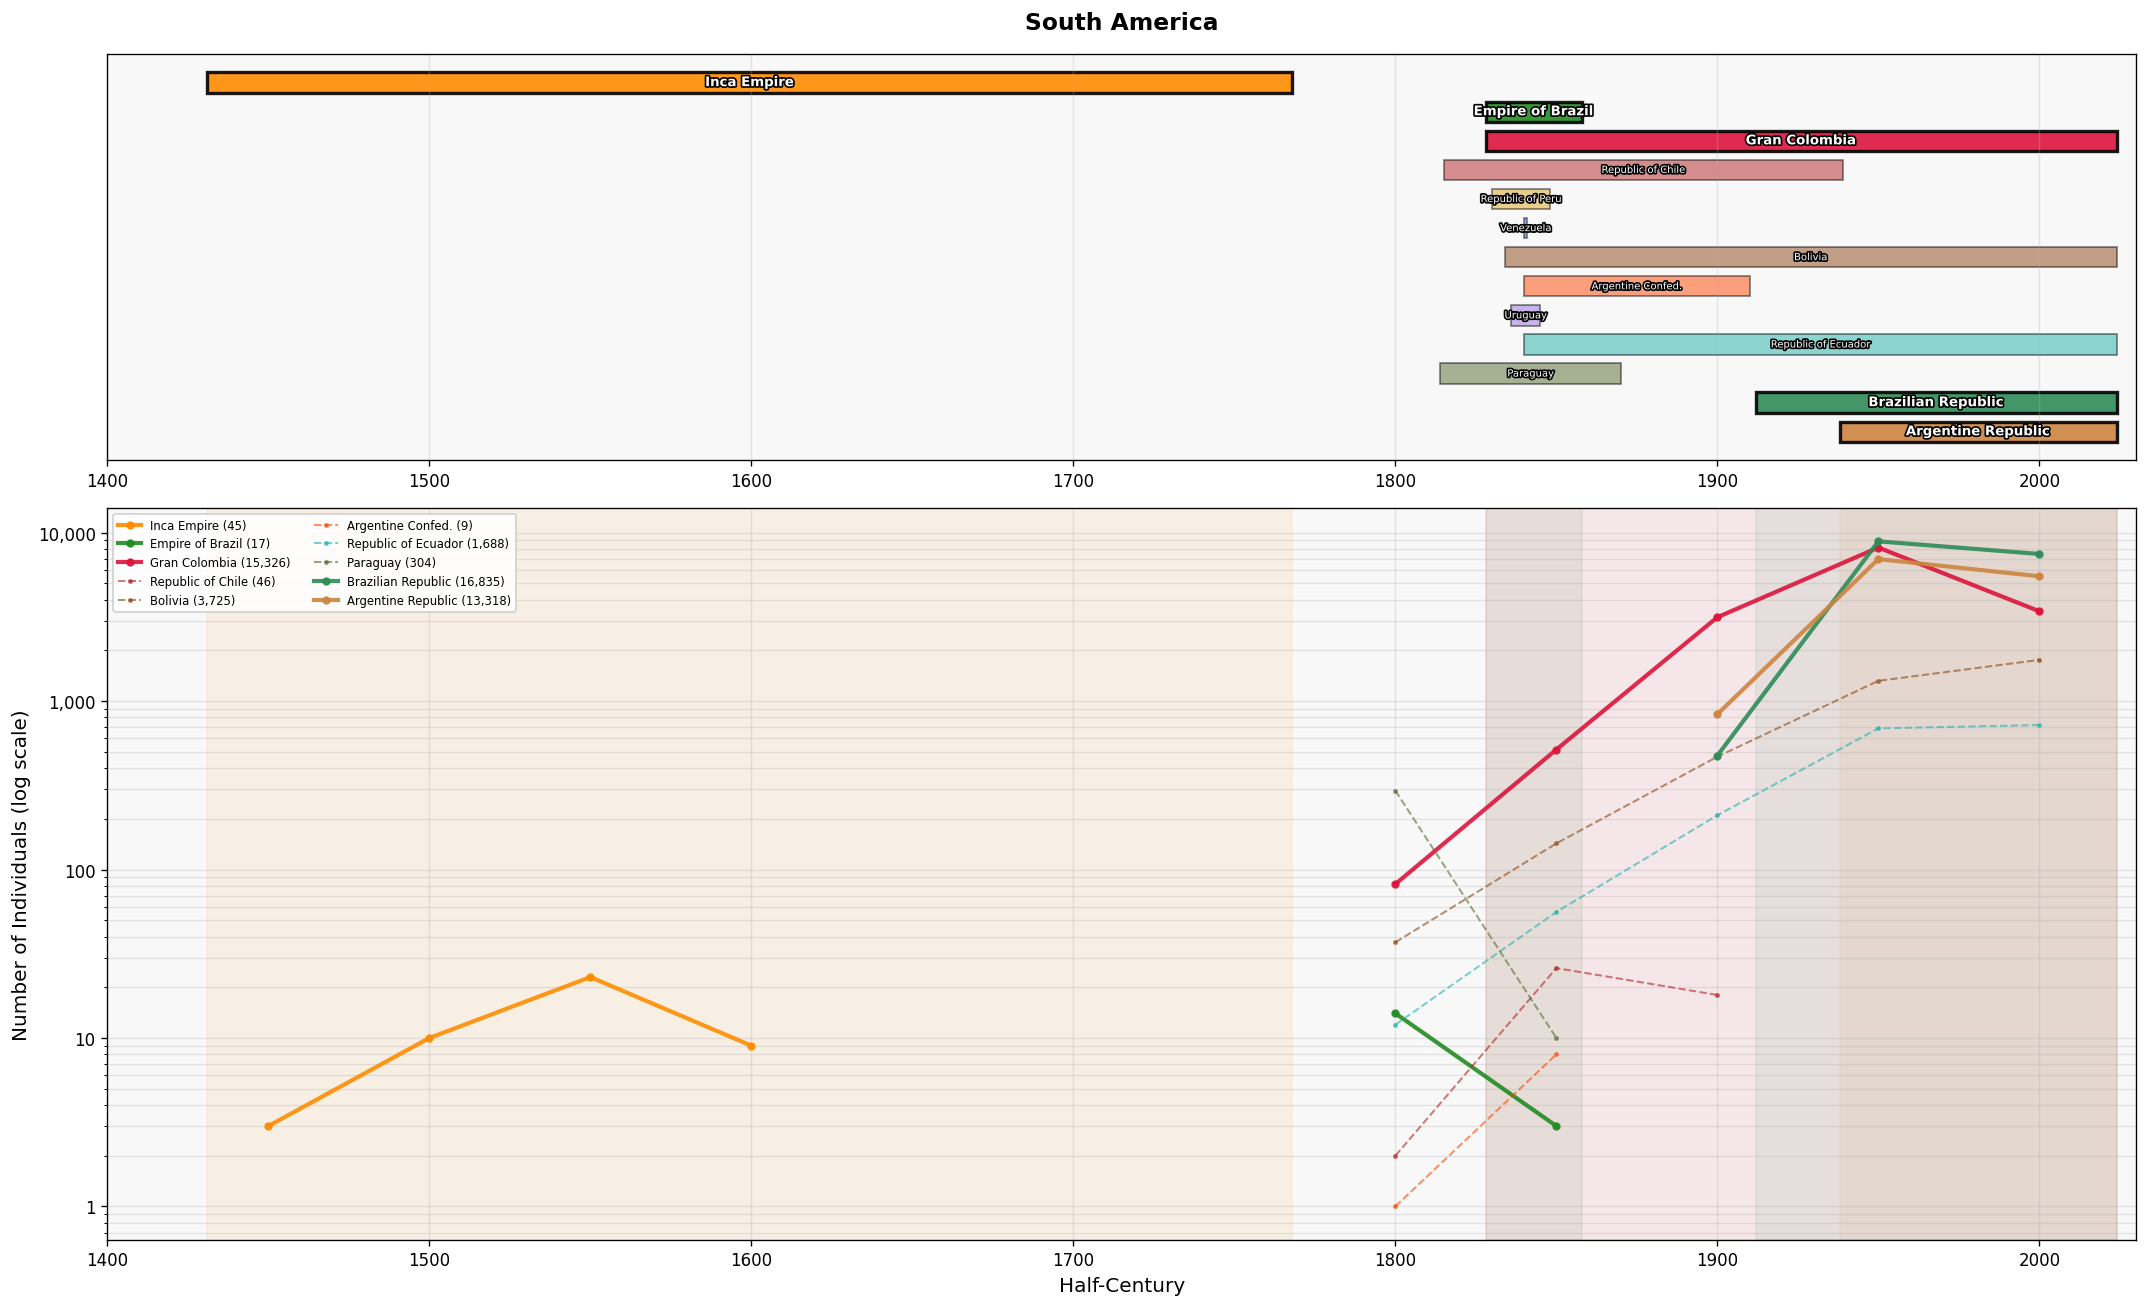

In [22]:
plot_timeline_and_lines(sa_data, 'South America', (1400, 2030), save_name='10_south_america.png')

---
## 11. Oceania

In [23]:
oceania = [
    (1435, 'Australia',    '#FF4500', True),
    (1456, 'New Zealand',  '#228B22', True),
]
oc_data = load_region_data(conn, oceania)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------


* Australia                     1947 CE - 2024 CE        51,877       3
* New Zealand                   1953 CE - 1968 CE             2       1


  Saved: dynasty_plots/11_oceania.png


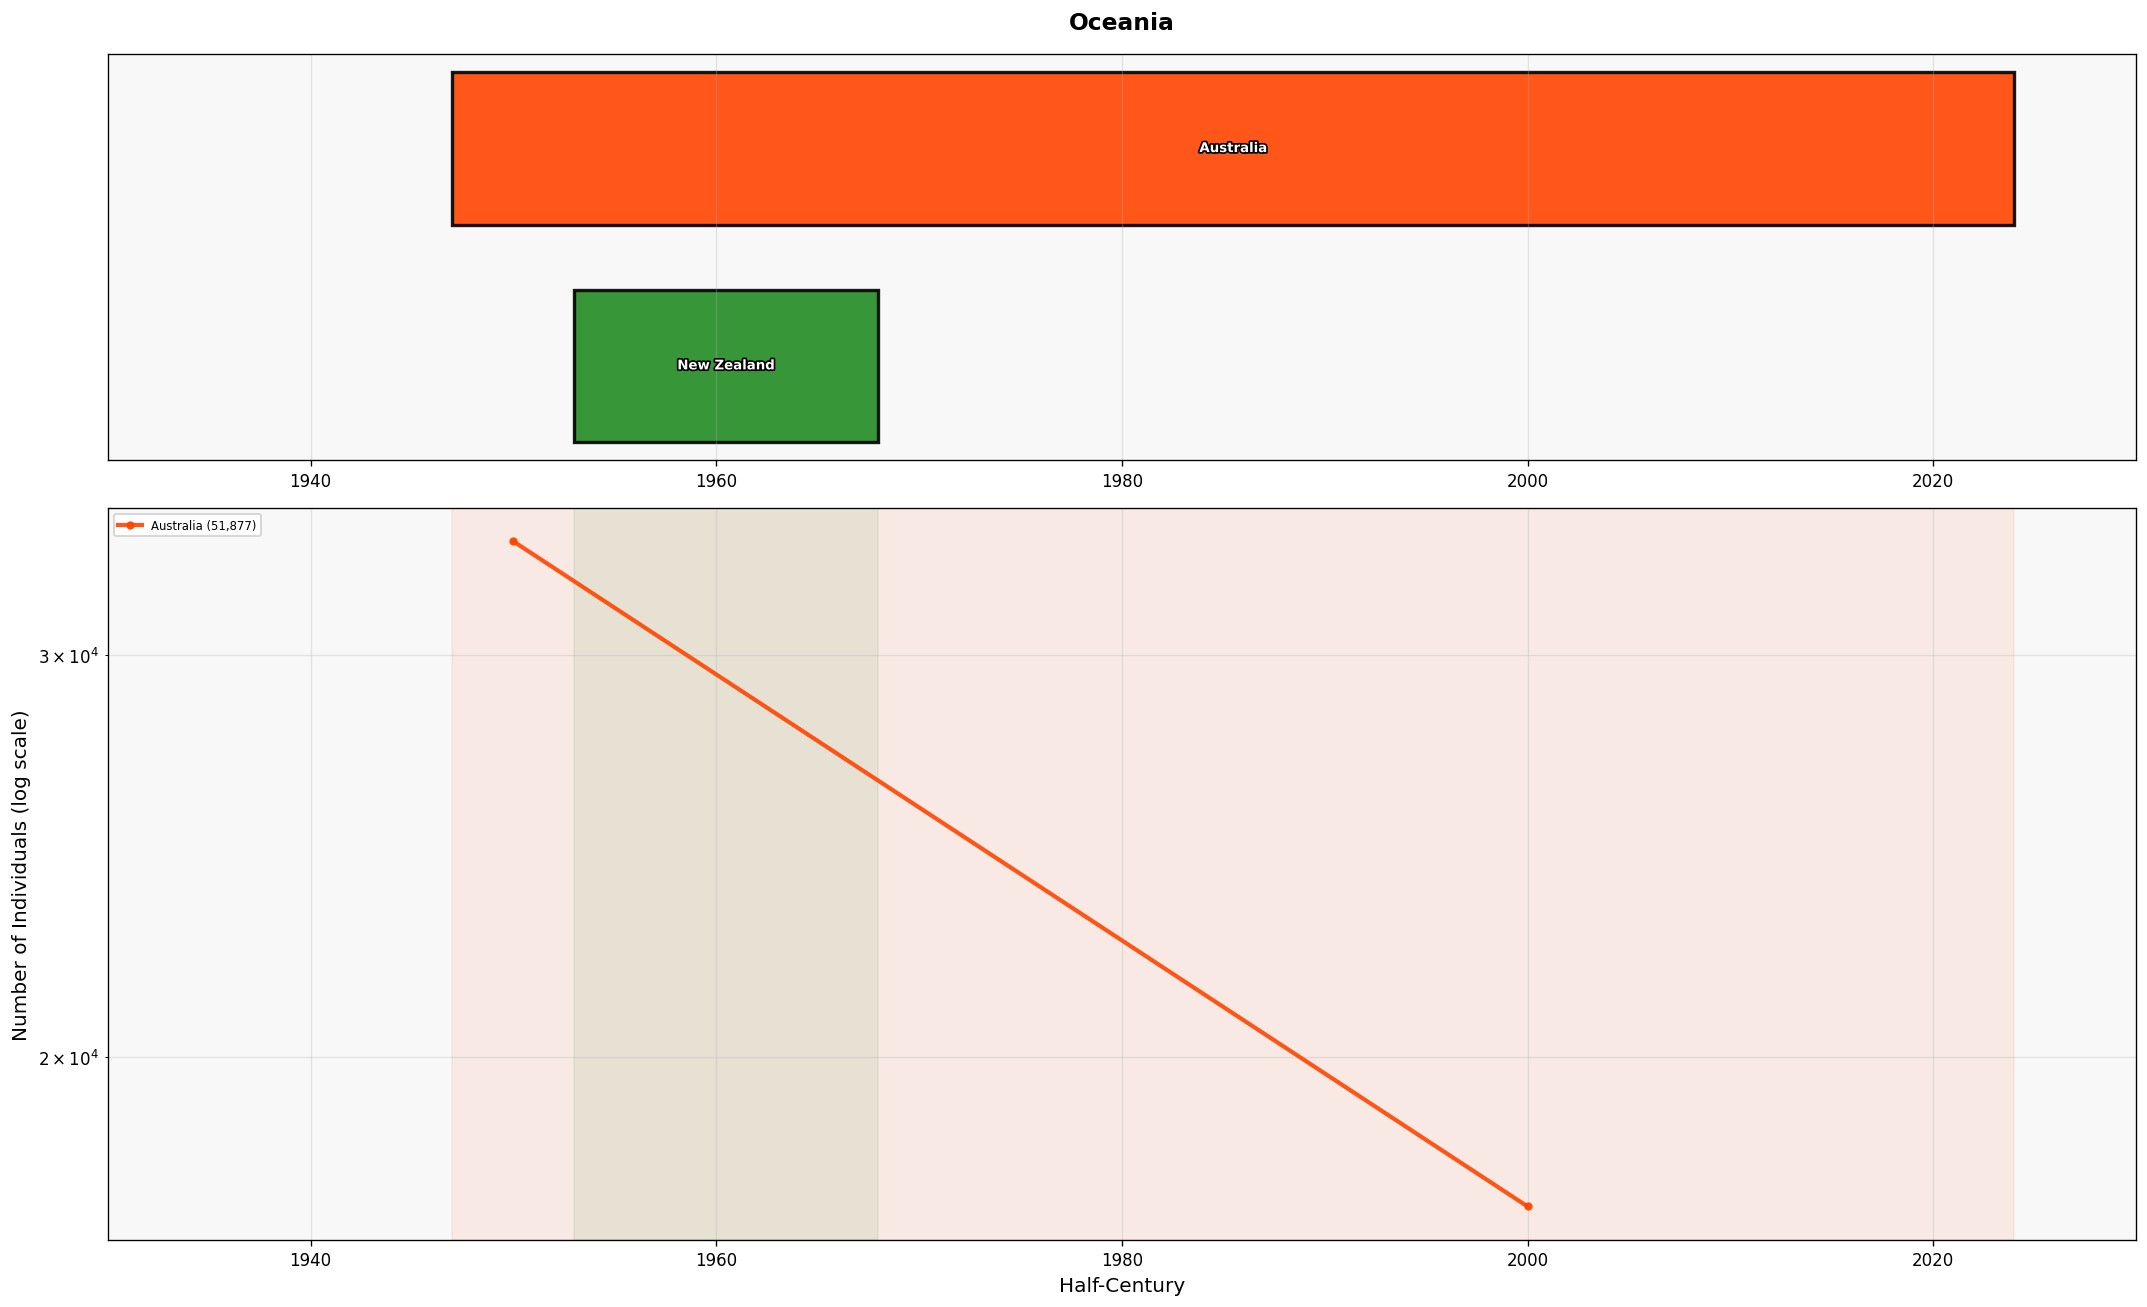

In [24]:
plot_timeline_and_lines(oc_data, 'Oceania', (1930, 2030), save_name='11_oceania.png')

---
## 12. Greek World

In [25]:
greek_world = [
    (22,   'Mycenaean Greece',       '#8B4513', False),
    (35,   'Greek City-States',      '#4169E1', True),
    (61,   'Macedonian Empire',      '#DAA520', True),
    (115,  'Ptolemaic Kingdom',      '#228B22', False),
    (125,  'Seleucid Empire',        '#9370DB', False),
    (142,  'Antigonid Macedonia',    '#708090', False),
    (138,  'Achaean League',         '#CD853F', False),
    (1269, 'First Hellenic Republic','#DC143C', True),
    (1438, 'Kingdom of Greece',      '#FF8C00', False),
    (1553, 'Third Hellenic Republic','#2E8B57', True),
]
gw_data = load_region_data(conn, greek_world)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
  Mycenaean Greece              1500 BCE - 1101 BCE             0       0
* Greek City-States             900 BCE - 601 BCE            41       7
* Macedonian Empire             750 BCE - 451 BCE             0       0
  Ptolemaic Kingdom             331 BCE - 92 BCE             2       2
  Seleucid Empire               307 BCE - 165 BCE             0       0
  Antigonid Macedonia           256 BCE - 113 CE             0       0
  Achaean League                277 BCE - 165 BCE            14       3
* First Hellenic Republic       1830 CE - 1841 CE             0       0
  Kingdom of Greece             1947 CE - 1955 CE             1       1
* Third Hellenic Republic       1979 CE - 2024 CE           139       2


  Saved: dynasty_plots/12_greek_world.png


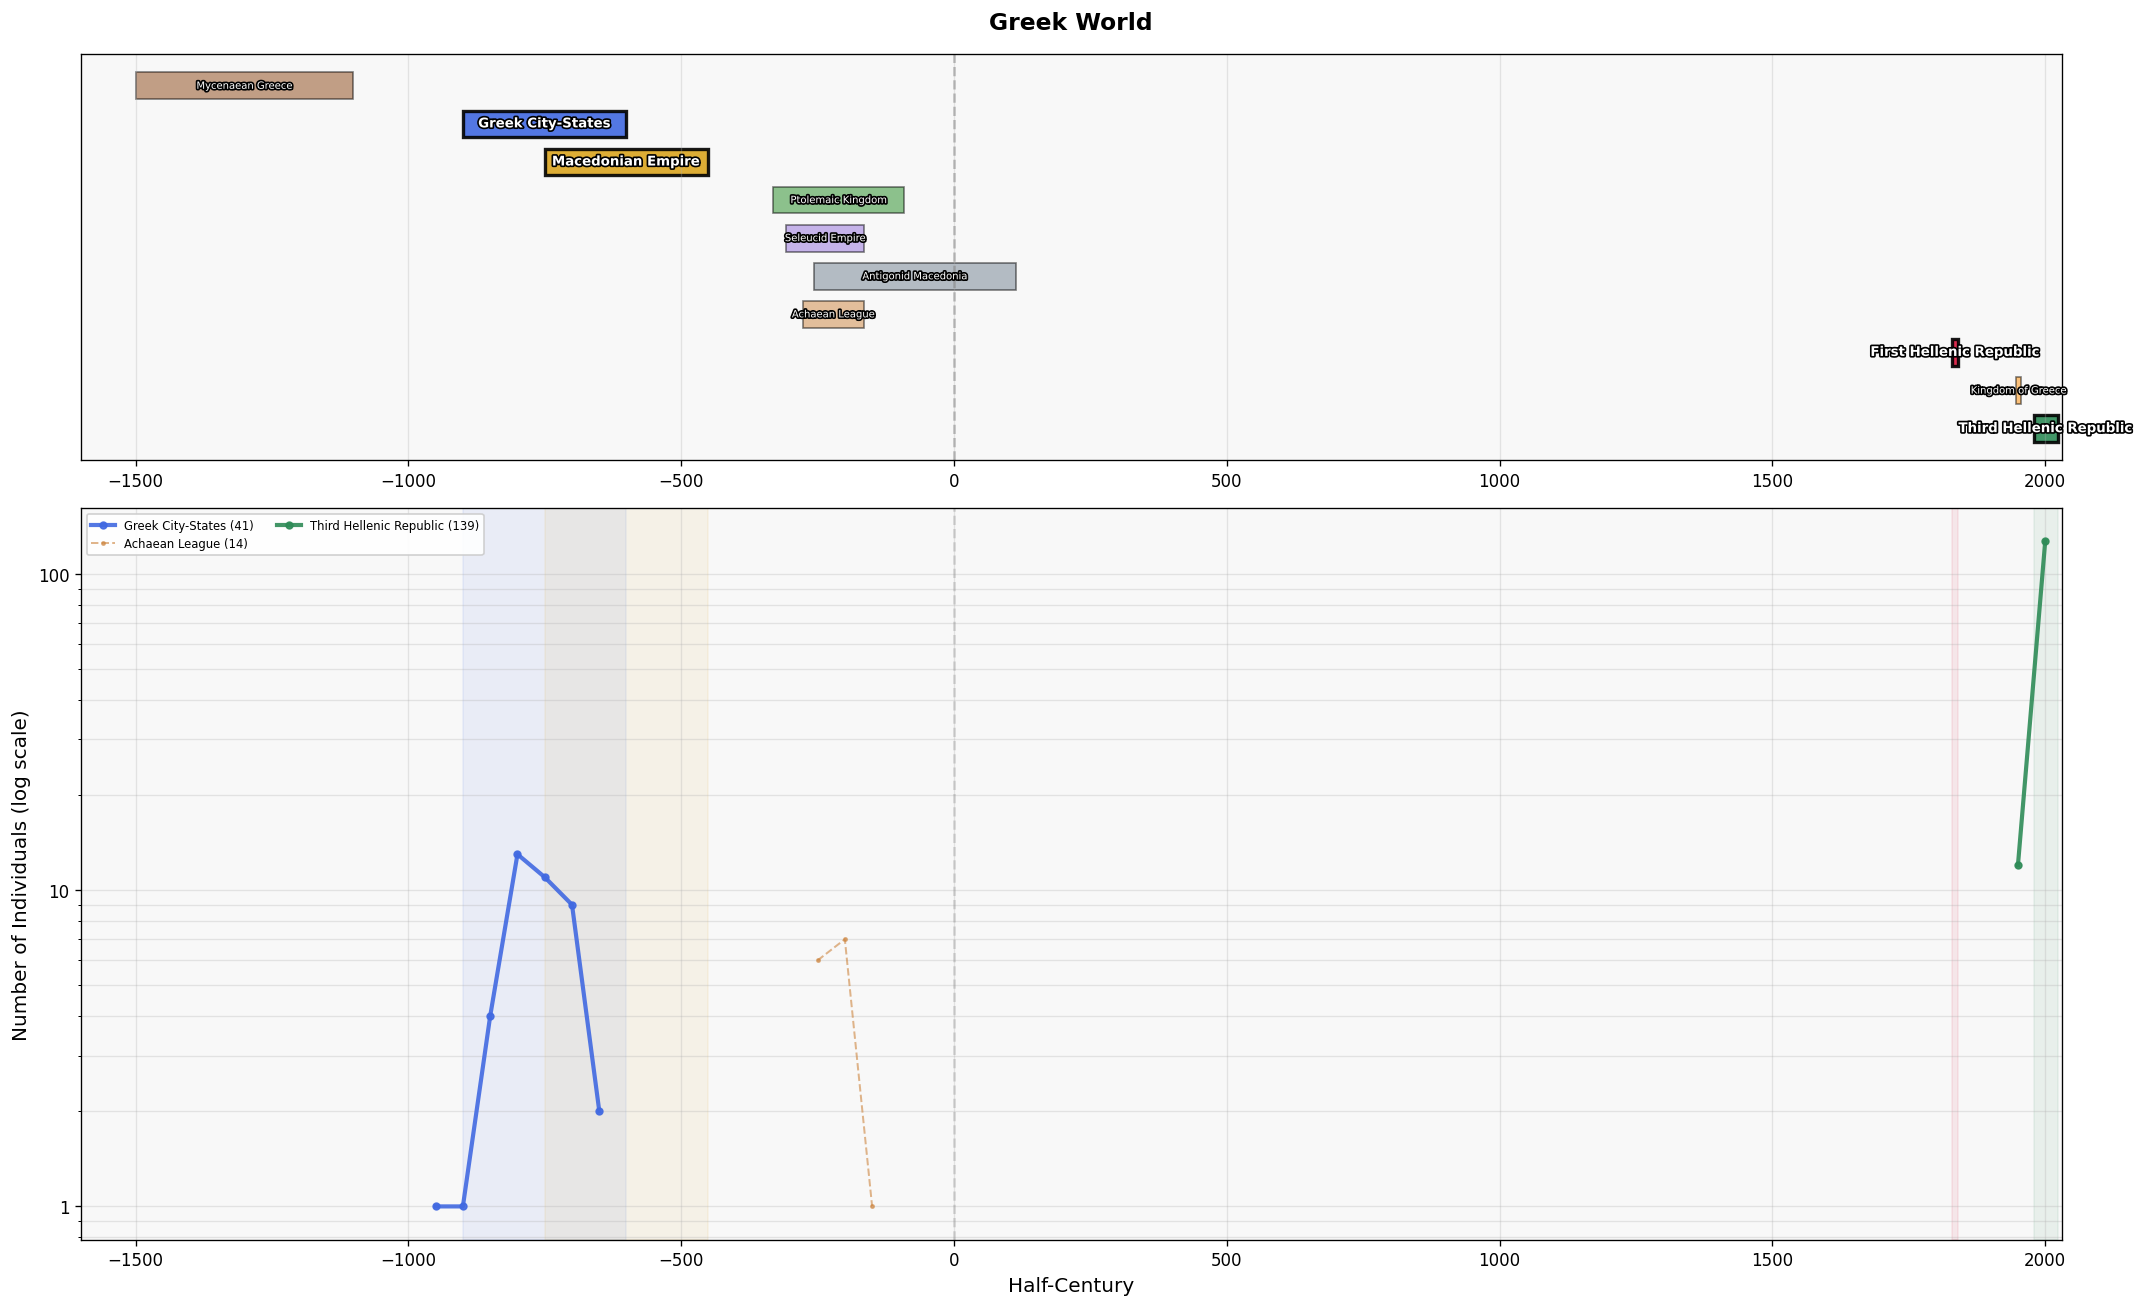

In [26]:
plot_timeline_and_lines(gw_data, 'Greek World', (-1600, 2030), save_name='12_greek_world.png')

---
## 13. Roman / Latin World

In [27]:
roman_world = [
    (41,   'Etruscans',              '#8B4513', False),
    (91,   'Roman Republic',          '#8B0000', True),
    (208,  'Roman Empire',            '#DC143C', True),
    (275,  'Western Roman Empire',    '#CD5C5C', False),
    (274,  'Eastern Roman Empire',    '#B22222', True),
    (380,  'Byzantine Empire',        '#9370DB', True),
]
rw_data = load_region_data(conn, roman_world)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
  Etruscans                     800 BCE - 701 BCE             0       0
* Roman Republic                550 BCE - 327 BCE           120       6
* Roman Empire                    43 CE - 237 CE             5       3
  Western Roman Empire           402 CE - 554 CE             0       0
* Eastern Roman Empire           402 CE - 409 CE             2       1
* Byzantine Empire               644 CE - 756 CE             1       1


  Saved: dynasty_plots/13_roman_world.png


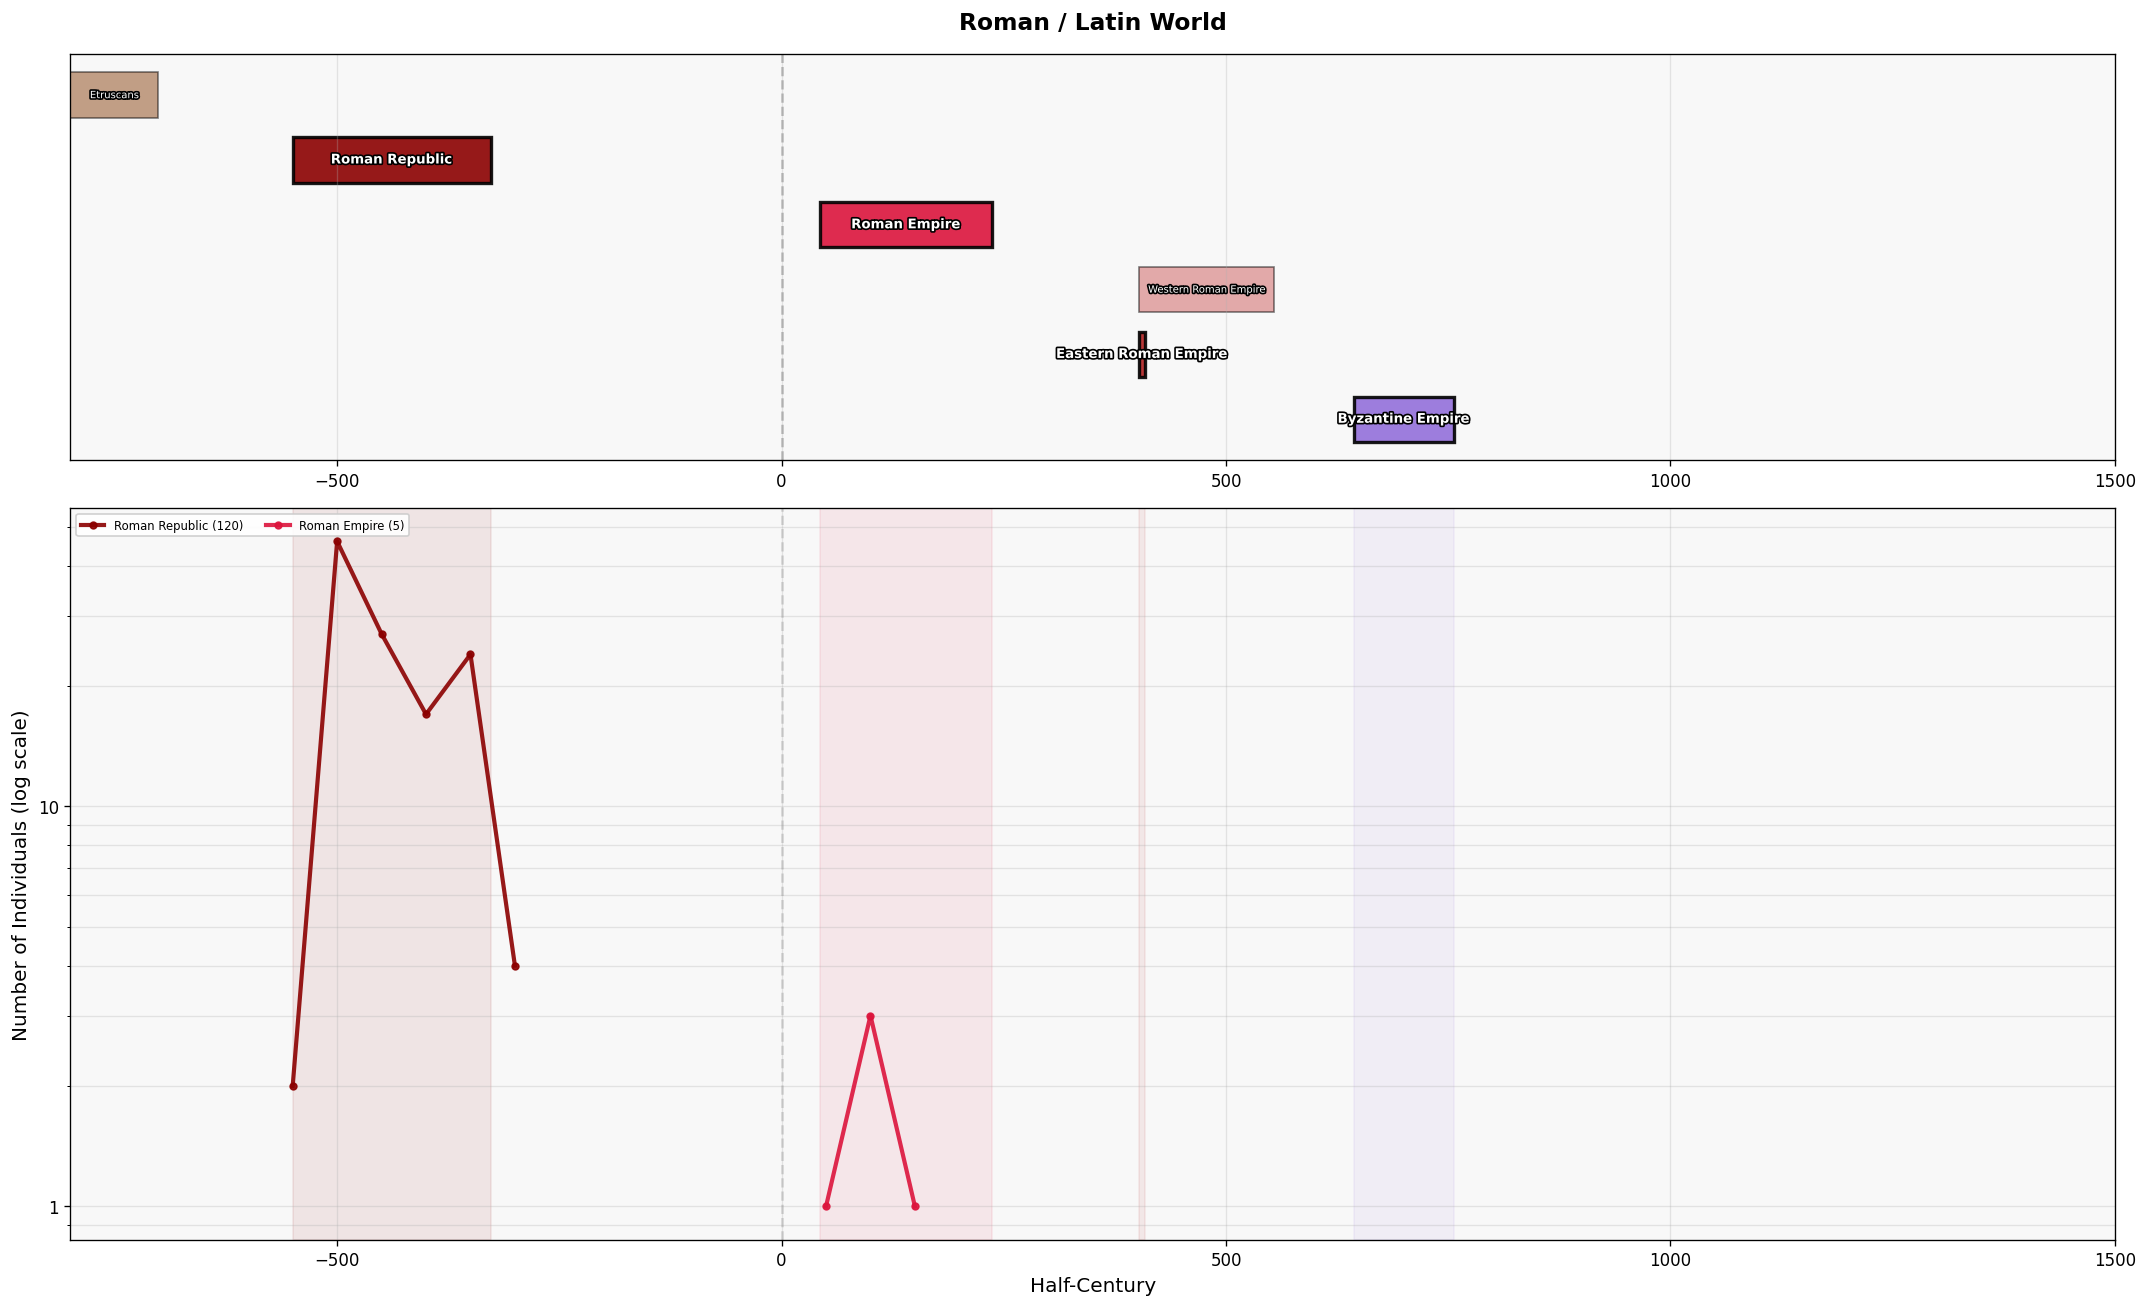

In [28]:
plot_timeline_and_lines(rw_data, 'Roman / Latin World', (-800, 1500), save_name='13_roman_world.png')

---
## 14. Chinese World

In [29]:
chinese_world = [
    (20,   'Shang Dynasty',               '#8B4513', False),
    (27,   'Zhou Dynasty',                 '#CD853F', False),
    (153,  'Qin Dynasty',                  '#FF8C00', False),
    (173,  'Han Dynasty',                  '#DC143C', True),
    (232,  'Cao Wei (Three Kingdoms)',      '#708090', False),
    (267,  'Northern Wei',                 '#556B2F', False),
    (355,  'Sui Dynasty',                  '#DAA520', False),
    (371,  'Tang Dynasty',                 '#4169E1', True),
    (559,  'Northern Song',                '#228B22', True),
    (616,  'Southern Song',                '#2E8B57', True),
    (808,  'Yuan Dynasty',                 '#B22222', True),
    (900,  'Ming Dynasty',                 '#FF4500', True),
    (1083, 'Qing Dynasty',                 '#9370DB', True),
    (1373, 'Republic of China',            '#20B2AA', True),
    (1465, "People's Republic of China",   '#8B0000', True),
]
cw_data = load_region_data(conn, chinese_world)

Polity                                    Period   Individuals    Bins
----------------------------------------------------------------------
  Shang Dynasty                 1600 BCE - 1001 BCE             9       6
  Zhou Dynasty                  1150 BCE - 501 BCE             0       0
  Qin Dynasty                   208 BCE - 153 CE            15       5
* Han Dynasty                   197 BCE - 47 BCE             5       2
  Cao Wei (Three Kingdoms)       261 CE - 269 CE             0       0
  Northern Wei                   387 CE - 401 CE             0       0
  Sui Dynasty                    592 CE - 859 CE             3       2
* Tang Dynasty                   630 CE - 979 CE             0       0


* Northern Song                  980 CE - 2024 CE        74,291      17
* Southern Song                 1046 CE - 1138 CE             0       0
* Yuan Dynasty                  1294 CE - 1325 CE             0       0
* Ming Dynasty                  1375 CE - 1467 CE             1       1
* Qing Dynasty                  1662 CE - 1774 CE            14       2
* Republic of China             1918 CE - 1918 CE             0       0
* People's Republic of China    1958 CE - 1959 CE             0       0


  Saved: dynasty_plots/14_chinese_world.png


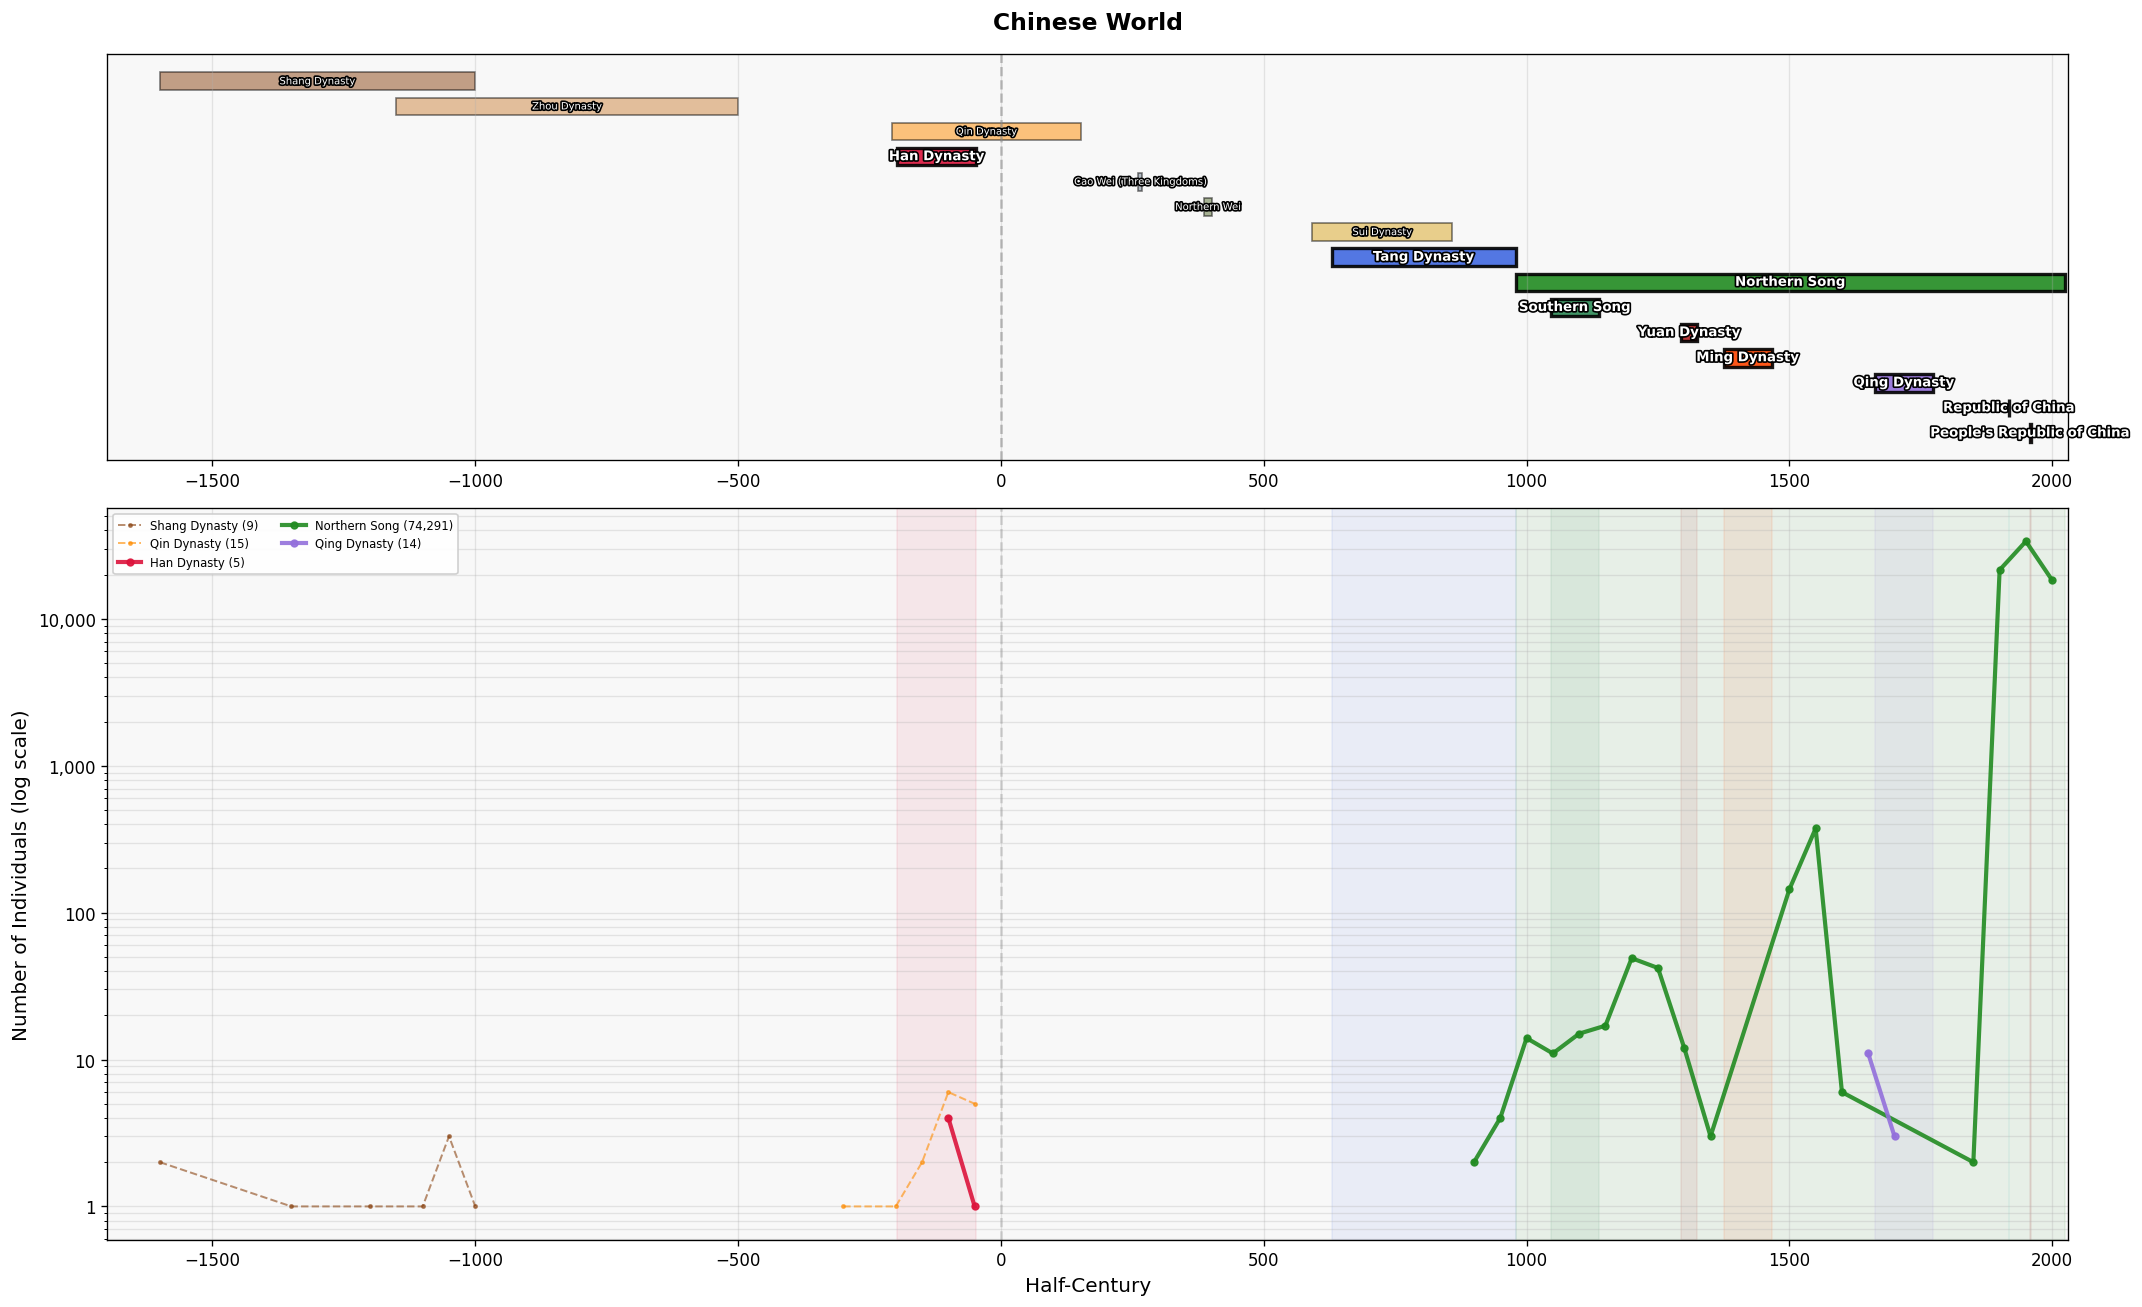

In [30]:
plot_timeline_and_lines(cw_data, 'Chinese World', (-1700, 2030), save_name='14_chinese_world.png')

---
## Summary: All Regions Compared

In [31]:
all_regions = [
    ('Western Europe', we_data),
    ('Eastern Europe', ee_data),
    ('Arab & Islamic World', ai_data),
    ('Mesopotamia & Persia', meso_data),
    ('Indian World', india_data),
    ('East Asia (Japan & Korea)', ea_data),
    ('Southeast Asia', sea_data),
    ('Africa', africa_data),
    ('North America', na_data),
    ('South America', sa_data),
    ('Oceania', oc_data),
    ('Greek World', gw_data),
    ('Roman / Latin World', rw_data),
    ('Chinese World', cw_data),
]

print(f"{'Region':<28s}  {'Polities':>9s}  {'Total Individuals':>18s}  {'Earliest':>10s}  {'Latest':>10s}")
print('=' * 90)
for region_name, rdata in all_regions:
    total = sum(d['total'] for d in rdata)
    earliest = min(d['from'] for d in rdata)
    latest = max(d['to'] for d in rdata)
    e_s = f"{abs(earliest)} BCE" if earliest < 0 else f"{earliest} CE"
    l_s = f"{abs(latest)} BCE" if latest < 0 else f"{latest} CE"
    print(f"  {region_name:<26s}  {len(rdata):>9d}  {total:>18,d}  {e_s:>10s}  {l_s:>10s}")

grand = sum(sum(d['total'] for d in rdata) for _, rdata in all_regions)
print('=' * 90)
print(f"  {'GRAND TOTAL':<26s}  {'':>9s}  {grand:>18,d}")

Region                         Polities   Total Individuals    Earliest      Latest
  Western Europe                     18                 358     550 BCE     2024 CE
  Eastern Europe                     13              71,180      644 CE     2024 CE
  Arab & Islamic World               17               5,905      638 CE     1870 CE
  Mesopotamia & Persia               10                 103    3400 BCE      554 CE
  Indian World                       13              26,661     318 BCE     2024 CE
  East Asia (Japan & Korea)          13               4,999        6 CE     1960 CE
  Southeast Asia                     17              68,870      215 CE     2024 CE
  Africa                             15                 745    3000 BCE     1870 CE
  North America                      10              24,843     218 BCE     2024 CE
  South America                      13              51,313     1431 CE     2024 CE
  Oceania                             2              51,879     1947 CE     

In [32]:
conn.close()